# 05 — Feature Engineering

**Input:** bảng `public.cleaned_city_temperature` được bàn giao từ `03_data_cleaning.ipynb`.

**Output chính:** bảng `public.city_temperature_features` trong PostgreSQL. Các file `data/processed/feature_engineered_data.csv.gz`, `data/processed/feature_metadata.json`, `data/processed/feature_statistics.csv.gz` và `data/sample/feature_sample.csv` là bản bàn giao bổ sung cho kiểm tra và demo.

Notebook giữ nguyên grain **một thành phố tại một tháng**. Mỗi dòng được định danh bằng khóa nghiệp vụ `observation_date + city_name + country_name + latitude + longitude`; biến mục tiêu là `city_average_temperature`.

Kịch bản được chọn là **dự báo một tháng kế tiếp**: tại thời điểm dự báo, mô hình được phép dùng thuộc tính tĩnh của địa điểm và dữ liệu các tháng trước, nhưng không được dùng phép đo của chính tháng đang dự báo.


## 1. Mục tiêu, vai trò và pipeline Feature Engineering

### 1.1. Mục tiêu của Notebook

Notebook 05 biến tập dữ liệu đã làm sạch thành một tập đặc trưng có căn cứ, an toàn theo thời gian và sẵn sàng cho huấn luyện mô hình. Các công việc chính gồm:

1. Chuyển các quan sát định lượng của Notebook 04 thành ý tưởng đặc trưng cụ thể.
2. Xây dựng bảy nhóm đặc trưng: thời gian, địa lý, tương tác, khí hậu theo vị trí, trễ/trượt, bối cảnh toàn cầu và chất lượng dữ liệu.
3. Tạo target statistics theo quá khứ tích lũy trong train và khóa thống kê trước validation/test.
4. Đánh giá/chọn feature bằng một cửa sổ riêng nằm trong train; không sử dụng validation/test.
5. Kiểm tra rò rỉ dữ liệu và đa cộng tuyến bằng provenance, thời gian và các phép kiểm tra tự động.
6. Lưu tập đặc trưng cùng metadata để Notebook 06 huấn luyện, tính Feature Importance/SHAP và đánh giá mô hình.


### 1.2. Vai trò của Feature Engineering trong dự án

Notebook 04 cho thấy các biến thô trong bảng sạch **không phản ánh đúng bản chất khí hậu** của dữ liệu:

- `month` và `quarter` chỉ có tương quan tuyến tính `r ≈ 0.10` với nhiệt độ, dù biên độ mùa vụ lên tới **13.04 °C**. Nguyên nhân là quan hệ tháng–nhiệt độ có tính **tuần hoàn**: tháng 12 và tháng 1 liền kề về khí hậu nhưng cách xa nhau về mặt số học.
- `year` và `decade` chỉ có `r ≈ 0.048`, dù xu hướng ấm lên là thật ở mức **xấp xỉ +0,027 °C/năm**. Tín hiệu dài hạn này bị biên độ mùa vụ và biên độ vĩ độ (lớn hơn nhiều) che lấp.
- `latitude` là driver địa lý mạnh nhất (`r = -0.467`) nhưng vì có dấu, nó trộn lẫn hai thông tin khác nhau: khoảng cách tới xích đạo và bán cầu.

Feature Engineering là bước biểu diễn lại các thông tin đó dưới dạng mà mô hình học được: mã hóa tuần hoàn cho mùa vụ, biến trôi thời gian cho xu hướng, khoảng cách tuyệt đối tới xích đạo cho vĩ độ. Đây cũng là bước duy nhất trong pipeline chịu trách nhiệm **chặn rò rỉ dữ liệu** trước khi mô hình được huấn luyện.

### 1.3. Kiến trúc pipeline

```text
public.cleaned_city_temperature  (grain City–month)
   ↓ chỉ đọc các cột cần dùng từ PostgreSQL
Sắp xếp theo vị trí → thời gian
   ↓ train ≤ 1983 | validation 1984–1993 | test 1994–2013
7 nhóm feature; target statistics train dùng expanding past-only
   ↓ chọn feature chỉ trên cửa sổ train 1974–1983
Kiểm tra leakage + multicollinearity chỉ bằng train
   ↓ khóa danh sách feature
public.city_temperature_features + metadata
   ↓
Notebook 06 — fit model bằng train, chọn bằng validation, báo cáo test
```

Các nguyên tắc thiết kế chính:

- **PostgreSQL là nguồn duy nhất.** Notebook dừng nếu thiếu cấu hình, không kết nối được hoặc chưa có bảng sạch.
- **Validation/test được khóa khỏi chọn feature.** Mọi metric lựa chọn feature chỉ dùng train 1974–1983.
- **Target statistics chống look-ahead.** Dòng train chỉ dùng lịch sử trước nó; validation/test dùng thống kê cố định chốt từ train đến 1983.
- **Feature động chỉ nhìn quá khứ.** Lag nhiệt độ, chỉ số toàn cầu và uncertainty không dùng tháng đang dự báo.
- **Feature Importance và SHAP thuộc Notebook 06.** Notebook 05 không fit mô hình và không in R² in-sample.
- **Feature suy ra trực tiếp từ target không được xuất.** `temp_anomaly_vs_climatology` chỉ phục vụ insight ở Mục 8.


## 2. Chuẩn bị môi trường và cấu hình

### 2.1. Nạp các thư viện cần thiết

`pandas` và `numpy` phục vụ xây dựng đặc trưng; `matplotlib` và `seaborn` vẽ biểu đồ đánh giá; `SQLAlchemy` kết hợp `psycopg2` dùng để đọc/ghi PostgreSQL; `python-dotenv` nạp cấu hình từ `.env` mà không ghi mật khẩu vào notebook.

In [1]:
import gc
import json
import os
import shutil
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5.5)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'pandas {pd.__version__} · numpy {np.__version__}')

pandas 3.0.3 · numpy 2.4.6


Notebook chỉ dùng các thư viện đã có trong `requirements.txt`. `scikit-learn` là **tùy chọn**: nếu môi trường chưa cài, Mục 6.3 sẽ tự chuyển sang phương án đánh giá thuần `pandas`/`numpy` và notebook vẫn chạy hết.

### 2.2. Xác định thư mục dự án và đầu ra

Notebook có thể được mở từ thư mục gốc, `notebooks_v1/` hoặc `notebooks_v2/`. Hàm dưới tìm project root dựa trên hai thư mục ổn định `data/` và `SQL/`, sau đó chuẩn bị các thư mục đầu ra.

In [2]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa cả data/ và SQL/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'SQL').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và SQL/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
SAMPLE_DIR = PROJECT_ROOT / 'data' / 'sample'
REPORT_IMAGES_DIR = PROJECT_ROOT / 'reports' / 'images'
for directory in (PROCESSED_DIR, SAMPLE_DIR, REPORT_IMAGES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLEANED_TABLE = 'cleaned_city_temperature'
FEATURE_TABLE = 'city_temperature_features'
METADATA_PATH = PROCESSED_DIR / 'feature_metadata.json'
FEATURE_STATS_PATH = PROCESSED_DIR / 'feature_statistics.csv.gz'
SAMPLE_PATH = SAMPLE_DIR / 'feature_sample.csv'

print('Project root   :', PROJECT_ROOT)
print('Input table    :', f'public.{CLEANED_TABLE}')
print('Processed dir  :', PROCESSED_DIR)
print('Report images  :', REPORT_IMAGES_DIR)


Project root   : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis
Input table    : public.cleaned_city_temperature
Processed dir  : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed
Report images  : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images


Đường dẫn in ra phải trỏ tới đúng project hiện tại. Notebook không đọc, ghi hoặc thay đổi bất kỳ file nào trong `data/raw/`.

### 2.3. Tham số cấu hình của notebook

Toàn bộ tham số được gom vào một cell để dễ kiểm soát:

- `FAST_MODE`: giới hạn số dòng sau khi PostgreSQL đã sắp xếp theo vị trí và thời gian; chỉ dùng để kiểm tra logic.
- `FEATURE_SELECTION_START_YEAR = 1974`: bắt đầu cửa sổ chọn feature nằm bên trong tập train.
- `FEATURE_FIT_CUTOFF_YEAR = 1983`: kết thúc tập train và là mốc chốt các thống kê phục vụ validation/test.
- `VALIDATION_START_YEAR = 1984` và `TRAIN_CUTOFF_YEAR = 1993`: validation 1984–1993 chỉ dành cho Notebook 06 chọn mô hình; test 1994–2013 chỉ dùng báo cáo cuối.
- `EVAL_SAMPLE_ROWS`: giới hạn mẫu lấy từ cửa sổ feature-selection 1974–1983, không lấy validation/test.
- `REDUNDANCY_SAMPLE_ROWS`: giới hạn mẫu đo tương quan giữa các feature, chỉ lấy từ tập train đến năm 1983.
- `OUTPUT_COMPRESSION`: điều khiển bản CSV kiểm tra; bảng PostgreSQL vẫn là đầu ra chính.


In [3]:
# --- Chế độ chạy ---------------------------------------------------------
FAST_MODE = False          # True: chạy thử nhanh trên một phần dữ liệu
FAST_MODE_ROWS = 400_000   # số dòng đầu theo thứ tự vị trí–thời gian

# --- Chia dữ liệu theo thời gian -----------------------------------------
FEATURE_SELECTION_START_YEAR = 1974  # 1974–1983: chọn feature bên trong train
FEATURE_FIT_CUTOFF_YEAR = 1983       # train và target-statistics kết thúc tại đây
VALIDATION_START_YEAR = 1984         # 1984–1993: Notebook 06 chọn mô hình
TRAIN_CUTOFF_YEAR = 1993             # test: 1994–2013, chỉ báo cáo cuối

# --- Đánh giá đặc trưng --------------------------------------------------
EVAL_SAMPLE_ROWS = 400_000
ETA_SQUARED_BINS = 20
RANDOM_SEED = 42

# --- Quy tắc lựa chọn đặc trưng (Mục 7) ---------------------------------
MIN_ETA_SQUARED = 0.005
MIN_ABS_PEARSON = 0.05
REDUNDANCY_THRESHOLD = 0.95
REDUNDANCY_SAMPLE_ROWS = 500_000  # chỉ lấy trong train <= 1983

# --- Đầu ra --------------------------------------------------------------
OUTPUT_COMPRESSION = 'gzip'
SAMPLE_ROWS = 50_000
TARGET_COLUMN = 'city_average_temperature'

rng = np.random.default_rng(RANDOM_SEED)
OUTPUT_PATH = PROCESSED_DIR / (
    'feature_engineered_data.csv.gz' if OUTPUT_COMPRESSION == 'gzip'
    else 'feature_engineered_data.csv'
)

if not (
    FEATURE_SELECTION_START_YEAR <= FEATURE_FIT_CUTOFF_YEAR
    < VALIDATION_START_YEAR <= TRAIN_CUTOFF_YEAR
):
    raise ValueError('Các mốc feature-selection/train/validation/test không đúng thứ tự.')

print(f'FAST_MODE                     : {FAST_MODE}')
print(f'FEATURE_SELECTION_START_YEAR  : {FEATURE_SELECTION_START_YEAR}')
print(f'FEATURE_FIT_CUTOFF_YEAR       : {FEATURE_FIT_CUTOFF_YEAR}')
print(f'VALIDATION_START_YEAR         : {VALIDATION_START_YEAR}')
print(f'TRAIN_CUTOFF_YEAR             : {TRAIN_CUTOFF_YEAR}')
print(f'EVAL_SAMPLE_ROWS              : {EVAL_SAMPLE_ROWS:,}')
print(f'REDUNDANCY_SAMPLE_ROWS        : {REDUNDANCY_SAMPLE_ROWS:,}')
print(f'Target                        : {TARGET_COLUMN}')
print(f'Output                        : {OUTPUT_PATH.name}')


FAST_MODE                     : False
FEATURE_SELECTION_START_YEAR  : 1974
FEATURE_FIT_CUTOFF_YEAR       : 1983
VALIDATION_START_YEAR         : 1984
TRAIN_CUTOFF_YEAR             : 1993
EVAL_SAMPLE_ROWS              : 400,000
REDUNDANCY_SAMPLE_ROWS        : 500,000
Target                        : city_average_temperature
Output                        : feature_engineered_data.csv.gz


Nếu `FAST_MODE = True`, mọi số liệu in ra sau đó chỉ mang tính kiểm tra logic và **không được dùng cho báo cáo**. Kết quả chính thức phải chạy với `FAST_MODE = False`.

### 2.4. Kết nối PostgreSQL bắt buộc


Notebook 05 chỉ đọc dữ liệu từ `public.cleaned_city_temperature` trong PostgreSQL để tuân thủ pipeline đã thống nhất từ Notebook 02–04. Không có nhánh fallback CSV: nếu database không khả dụng, notebook dừng và báo rõ lỗi để tránh vô tình dùng một bản dữ liệu khác.

Tạo file `.env` ở project root từ `.env.example`:

```text
DB_HOST=localhost
DB_PORT=5432
DB_NAME=climate_db
DB_USER=postgres
DB_PASSWORD=<mật khẩu PostgreSQL trên máy đang chạy>
```


In [4]:
ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {ENV_PATH}. Notebook 05 chỉ đọc dữ liệu từ PostgreSQL.'
    )

from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

load_dotenv(ENV_PATH, override=False)
required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise ValueError(f'.env thiếu các biến: {missing_env}')

DB_ENGINE = create_engine(
    URL.create(
        drivername='postgresql+psycopg2',
        username=os.environ['DB_USER'],
        password=os.environ['DB_PASSWORD'],
        host=os.environ['DB_HOST'],
        port=int(os.environ['DB_PORT']),
        database=os.environ['DB_NAME'],
    ),
    pool_pre_ping=True,
    connect_args={'connect_timeout': 10},
)

check_sql = text(
    'SELECT current_database() AS database_name, '
    f"to_regclass('public.{CLEANED_TABLE}') IS NOT NULL AS source_table_exists"
)
with DB_ENGINE.connect() as connection:
    db_check = pd.read_sql_query(check_sql, connection)

display(db_check)
if not bool(db_check.loc[0, 'source_table_exists']):
    raise RuntimeError(
        f'Không tìm thấy public.{CLEANED_TABLE}. Hãy hoàn thành Notebook 03 trước.'
    )

DB_AVAILABLE = True
DATA_SOURCE = f'POSTGRESQL · public.{CLEANED_TABLE}'
print('PostgreSQL:', f"Đã kết nối {db_check.loc[0, 'database_name']}.public.{CLEANED_TABLE}")


,database_name,source_table_exists
0,climate_db,True


PostgreSQL: Đã kết nối climate_db.public.cleaned_city_temperature


Cell kết nối chỉ thực hiện truy vấn kiểm tra database và sự tồn tại của bảng nguồn; mật khẩu không được hiển thị. Notebook chỉ tiếp tục khi kết nối thành công và `public.cleaned_city_temperature` tồn tại.


## 3. Đọc dữ liệu đã làm sạch

### 3.1. Xác nhận data contract từ Notebook 03

Theo Notebook 03, bảng sạch phải có **5.579.085 dòng**, **32 cột**, **50 quốc gia**, thời gian từ `1863-01-01` đến `2013-09-01` và không còn dòng nào thiếu biến mục tiêu. Các hằng số dưới đây được dùng để đối chiếu sau khi nạp dữ liệu.

In [5]:
EXPECTED_CLEAN_ROWS = 5_579_085
EXPECTED_COUNTRIES = 50
EXPECTED_MIN_DATE = pd.Timestamp('1863-01-01')
EXPECTED_MAX_DATE = pd.Timestamp('2013-09-01')

BUSINESS_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
]
LOCATION_KEY_COLUMNS = ['city_name', 'country_name', 'latitude', 'longitude']

print(f'Kỳ vọng {EXPECTED_CLEAN_ROWS:,} dòng · {EXPECTED_COUNTRIES} quốc gia · '
      f'{EXPECTED_MIN_DATE.date()} → {EXPECTED_MAX_DATE.date()}')

Kỳ vọng 5,579,085 dòng · 50 quốc gia · 1863-01-01 → 2013-09-01


### 3.2. Chọn cột cần dùng và kiểu dữ liệu tối ưu

Bảng sạch có 32 cột nhưng Notebook 05 chỉ đọc **16 cột** để giảm thời gian truyền và bộ nhớ.

Các cột nhiệt độ cùng tháng chỉ được đọc khi cần chứng minh hoặc tạo phiên bản lag an toàn:

- `major_city_average_temperature` và `country_average_temperature` được dùng ở Mục 6.5 để chứng minh rò rỉ rồi loại.
- `land_average_temperature` chỉ là nguồn để tạo `land_temperature_lag_1`; bản cùng tháng không được đưa vào candidate feature.
- `city_average_temperature_uncertainty` chỉ là nguồn để tạo `city_uncertainty_lag_1`; uncertainty cùng tháng không được dùng dự báo.

Các biến `land_max_temperature`, `land_min_temperature` và `land_and_ocean_average_temperature` không cần đọc vì đều là bối cảnh cùng tháng, không phù hợp kịch bản dự báo một tháng kế tiếp.


In [6]:
CALENDAR_COLUMNS = ['year', 'month', 'quarter', 'decade']
TEMPERATURE_COLUMNS = [
    TARGET_COLUMN,                              # biến mục tiêu
    'city_average_temperature_uncertainty',     # nguồn tạo uncertainty lag 1
    'land_average_temperature',                 # nguồn tạo chỉ số toàn cầu lag 1
    'country_average_temperature',              # đọc để chứng minh rủi ro ở Mục 6.5
    'major_city_average_temperature',           # đọc để chứng minh rò rỉ ở Mục 6.5
]
FLAG_COLUMNS = ['is_major_city', 'city_temperature_iqr_outlier']

USED_COLUMNS = BUSINESS_KEY_COLUMNS + CALENDAR_COLUMNS + TEMPERATURE_COLUMNS + FLAG_COLUMNS

# Kiểu dữ liệu nhỏ nhất còn biểu diễn đúng giá trị (xem CHECK constraint của Notebook 03).
READ_DTYPES = {
    'year': 'int16', 'month': 'int8', 'quarter': 'int8', 'decade': 'int16',
    'city_name': 'category', 'country_name': 'category',
    'latitude': 'float32', 'longitude': 'float32',
    **{column: 'float32' for column in TEMPERATURE_COLUMNS},
}

print(f'Đọc {len(USED_COLUMNS)}/32 cột:')
for index, column in enumerate(USED_COLUMNS, start=1):
    print(f'  {index:2d}. {column}')

Đọc 16/32 cột:
   1. observation_date
   2. city_name
   3. country_name
   4. latitude
   5. longitude
   6. year
   7. month
   8. quarter
   9. decade
  10. city_average_temperature
  11. city_average_temperature_uncertainty
  12. land_average_temperature
  13. country_average_temperature
  14. major_city_average_temperature
  15. is_major_city
  16. city_temperature_iqr_outlier


`city_name` và `country_name` dùng `category` vì chỉ có 3.070 và 50 giá trị duy nhất trên hơn 5,5 triệu dòng — hạ từ chuỗi Python xuống mã số nguyên tiết kiệm phần lớn bộ nhớ của hai cột này. Các cột nhiệt độ dùng `float32` thay vì `float64`: dữ liệu gốc chỉ có 3 chữ số thập phân nên không mất thông tin, mà giảm một nửa bộ nhớ.

### 3.3. Nạp dữ liệu theo từng chunk

Dữ liệu được truy vấn từ PostgreSQL theo các chunk 500.000 dòng để giảm bộ nhớ đỉnh. Truy vấn có `ORDER BY country_name, city_name, latitude, longitude, observation_date`, giúp chuỗi của từng vị trí luôn đúng thứ tự trước khi tạo lag.


In [7]:
CHUNK_SIZE = 500_000


def compact_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Chuẩn hóa kiểu dữ liệu của một chunk trước khi ghép DataFrame lớn."""
    chunk['observation_date'] = pd.to_datetime(
        chunk['observation_date'], errors='raise'
    )
    for column, dtype in READ_DTYPES.items():
        if column in chunk.columns and chunk[column].dtype.name != dtype:
            chunk[column] = chunk[column].astype(dtype)
    for column in FLAG_COLUMNS:
        if chunk[column].dtype != bool:
            chunk[column] = chunk[column].astype('bool')
    return chunk


limit_clause = f' LIMIT {FAST_MODE_ROWS}' if FAST_MODE else ''
query = text(
    f"SELECT {', '.join(USED_COLUMNS)} FROM public.{CLEANED_TABLE} "
    'ORDER BY country_name, city_name, latitude, longitude, observation_date'
    f'{limit_clause}'
)

parts = []
with DB_ENGINE.connect() as connection:
    for chunk in pd.read_sql_query(query, connection, chunksize=CHUNK_SIZE):
        parts.append(compact_chunk(chunk))

if not parts:
    raise RuntimeError(f'public.{CLEANED_TABLE} không có dữ liệu.')

feature_df = pd.concat(parts, ignore_index=True)[USED_COLUMNS]

# LIMIT có thể cắt dở chuỗi của vị trí cuối. Loại vị trí đó trước mọi phép
# chia thời gian để DataFrame và các mask luôn cùng chỉ mục.
if FAST_MODE:
    last_location = feature_df.iloc[-1][LOCATION_KEY_COLUMNS]
    last_location_mask = pd.Series(True, index=feature_df.index)
    for column in LOCATION_KEY_COLUMNS:
        last_location_mask &= feature_df[column].eq(last_location[column])
    if (~last_location_mask).any():
        feature_df = feature_df.loc[~last_location_mask].reset_index(drop=True)

print(f'Nguồn dữ liệu : {DATA_SOURCE}')
print(f'Đã nạp        : {len(feature_df):,} dòng × {feature_df.shape[1]} cột')


Nguồn dữ liệu : POSTGRESQL · public.cleaned_city_temperature
Đã nạp        : 5,579,085 dòng × 16 cột


Dòng `Nguồn dữ liệu` phải luôn là `POSTGRESQL · public.cleaned_city_temperature`. Số cột đọc vào phải bằng 16; nếu kết nối hoặc data contract sai, notebook dừng thay vì chuyển nguồn.


### 3.4. Kiểm tra data contract, grain và bộ nhớ

Trước khi xây dựng đặc trưng, notebook kiểm tra ba điều kiện. Hai điều kiện đầu là **lỗi cấu trúc** và sẽ làm dừng notebook, vì mọi đặc trưng trễ phía sau đều dựa vào giả định grain duy nhất:

1. Khóa nghiệp vụ City–month phải duy nhất.
2. Biến mục tiêu không được có giá trị thiếu.

Điều kiện thứ ba — row count, số quốc gia, khoảng thời gian — chỉ **cảnh báo**, vì `FAST_MODE` cố tình đọc ít dòng hơn và người dùng có thể chạy lại pipeline với phạm vi khác.

In [8]:
duplicate_key_rows = int(feature_df.duplicated(subset=BUSINESS_KEY_COLUMNS).sum())
missing_target_rows = int(feature_df[TARGET_COLUMN].isna().sum())
if duplicate_key_rows:
    raise RuntimeError(
        f'Có {duplicate_key_rows:,} dòng trùng khóa nghiệp vụ City–month. '
        'Đặc trưng trễ yêu cầu grain duy nhất; hãy kiểm tra lại Notebook 03.'
    )
if missing_target_rows:
    raise RuntimeError(
        f'Có {missing_target_rows:,} dòng thiếu {TARGET_COLUMN}. '
        'Notebook 03 phải loại các dòng này trước khi bàn giao.'
    )

actual_countries = int(feature_df['country_name'].nunique())
actual_locations = int(feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True).ngroups)
contract_report = pd.DataFrame(
    {
        'Expected': [EXPECTED_CLEAN_ROWS, EXPECTED_COUNTRIES,
                     EXPECTED_MIN_DATE.date(), EXPECTED_MAX_DATE.date()],
        'Actual': [len(feature_df), actual_countries,
                   feature_df['observation_date'].min().date(),
                   feature_df['observation_date'].max().date()],
    },
    index=['Row count', 'Country count', 'Min observation date', 'Max observation date'],
)
contract_report['Match'] = contract_report['Expected'].astype(str) == contract_report['Actual'].astype(str)
display(contract_report)

print(f'Số vị trí (city+country+toạ độ): {actual_locations:,}')
print(f'Bộ nhớ đang dùng               : '
      f'{feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
print(f'Khóa nghiệp vụ duy nhất        : PASS ({duplicate_key_rows} dòng trùng)')
print(f'Biến mục tiêu đầy đủ           : PASS ({missing_target_rows} dòng thiếu)')

if not contract_report['Match'].all():
    if FAST_MODE:
        print('\nLƯU Ý: FAST_MODE đang bật nên row count nhỏ hơn contract là bình thường.')
    else:
        print('\nCẢNH BÁO: dữ liệu không khớp contract của Notebook 03. '
              'Hãy kiểm tra lại phiên bản bảng sạch trước khi dùng kết quả cho báo cáo.')

,Expected,Actual,Match
Row count,5579085,5579085,True
Country count,50,50,True
Min observation date,1863-01-01,1863-01-01,True
Max observation date,2013-09-01,2013-09-01,True


Số vị trí (city+country+toạ độ): 3,119
Bộ nhớ đang dùng               : 400.5 MB
Khóa nghiệp vụ duy nhất        : PASS (0 dòng trùng)
Biến mục tiêu đầy đủ           : PASS (0 dòng thiếu)


Hai dòng `PASS` xác nhận grain City–month duy nhất và biến mục tiêu đầy đủ — đây là điều kiện bắt buộc để các đặc trưng trễ ở Mục 5.6 tra cứu đúng theo lịch. Bộ nhớ in ra nên ở mức vài trăm MB nhờ các kiểu dữ liệu đã hạ ở Mục 3.2; nếu con số này lên tới nhiều GB, rất có thể `READ_DTYPES` chưa được áp dụng.

In [9]:
display(feature_df.head())
display(feature_df.dtypes.to_frame('dtype'))

,observation_date,city_name,country_name,latitude,longitude,year,month,quarter,decade,city_average_temperature,city_average_temperature_uncertainty,land_average_temperature,country_average_temperature,major_city_average_temperature,is_major_city,city_temperature_iqr_outlier
0,1863-01-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,1,1,1860,20.3650,2.9650,3.0340,20.2260,NaN,False,False
1,1863-02-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,2,1,1860,20.3580,3.0540,3.2530,19.5130,NaN,False,False
2,1863-03-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,3,1,1860,16.6370,1.6250,4.6820,16.4700,NaN,False,False
3,1863-04-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,4,2,1860,13.9310,1.6410,7.9310,13.5310,NaN,False,False
4,1863-05-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,5,2,1860,9.1430,1.6530,11.0810,9.0090,NaN,False,False


,dtype
observation_date,datetime64[s]
city_name,str
country_name,str
latitude,float32
longitude,float32
year,int16
month,int8
quarter,int8
decade,int16
city_average_temperature,float32


Bảng mẫu cho thấy dữ liệu đã ở đúng grain City–month với các cột nghiệp vụ trực tiếp. Cột `major_city_average_temperature` phần lớn là `NaN` — đúng như Notebook 04 mô tả: chỉ khoảng 2,7% dòng thuộc nhóm Major City.

## 4. Ý tưởng xây dựng Feature từ kết quả EDA

### 4.1. Chuyển kết quả EDA thành ý tưởng Feature

Mục này chuyển các phát hiện của Notebook 04 thành tập feature ứng viên cho dự báo nhiệt độ thành phố ở tháng kế tiếp. Một biến chỉ được đề xuất khi:

1. Có cơ sở từ EDA hoặc đặc điểm vật lý của khí hậu.
2. Có thể biết tại thời điểm dự báo hoặc chỉ sử dụng lịch sử đã xảy ra.
3. Có thể tạo nhất quán cho train, validation và test mà không dùng thông tin tương lai.

| Nhóm ý tưởng | Feature ứng viên chính | Nguồn thông tin | Thời điểm sử dụng |
|---|---|---|---|
| Chu kỳ thời gian | `month_sin`, `month_cos`, `climatic_month_sin`, `climatic_month_cos`, `years_since_start` | Ngày dự báo | Biết trước |
| Địa lý | `latitude`, `abs_latitude`, `hemisphere_north`, `longitude`, `is_major_city` | Thuộc tính vị trí | Tĩnh |
| Tương tác khí hậu | `abslat_x_month_sin`, `abslat_x_month_cos`, `abslat_x_years` | Thời gian × địa lý | Biết trước |
| Khí hậu theo địa điểm | `loc_month_climatology`, `loc_mean_temperature`, `loc_temperature_std`, `loc_climatology_imputed` | Lịch sử target | Past-only/fixed train stat |
| Lịch sử thành phố | `temp_lag_1`, `temp_lag_12`, `temp_roll_mean_12`, `temp_roll_std_12`, `temp_anomaly_lag_12` | Các tháng trước | Lịch sử đã quan sát |
| Bối cảnh toàn cầu | `land_temperature_lag_1`, `land_anomaly_lag_1` | Tháng trước | Lịch sử đã quan sát |
| Chất lượng phép đo | `city_uncertainty_lag_1` | Tháng trước | Lịch sử đã quan sát |

Đây mới là danh sách ứng viên. Mục 6 đo tín hiệu trên cửa sổ feature-selection 1974–1983 thuộc train; Mục 7 mới quyết định giữ/loại. Validation và test không tham gia quá trình này.


#### 4.1.1. Feature biểu diễn chu kỳ thời gian

EDA cho thấy nhiệt độ thay đổi rõ rệt theo tháng. Tuy nhiên, nếu dùng trực tiếp số tháng từ 1 đến 12, mô hình sẽ hiểu tháng 12 cách xa tháng 1, trong khi hai tháng này thực tế nằm cạnh nhau trên chu kỳ năm. Vì vậy, tháng được mã hóa bằng hai thành phần tuần hoàn:


$$\text{month\_sin}=\sin\left(2\pi\frac{month}{12}\right),\qquad
\text{month\_cos}=\cos\left(2\pi\frac{month}{12}\right)$$


Hai feature `month_sin` và `month_cos` giúp mô hình nhận biết vị trí của một tháng trên vòng tuần hoàn và giữ được quan hệ gần nhau giữa tháng 12 và tháng 1.

**Vì sao phải dùng đồng thời cả `sin` và `cos`?** Nếu chỉ dùng một hàm, một số tháng khác nhau có thể có cùng giá trị hoặc gần như cùng giá trị. Chẳng hạn, với mã hóa `sin`, tháng 1 và tháng 5 cùng có giá trị xấp xỉ `0.50`; tháng 7 và tháng 11 cùng có giá trị xấp xỉ `-0.50`; tháng 6 và tháng 12 cùng có giá trị gần `0`. Khi đó, mô hình bị mất thông tin về **pha mùa**: biết một điểm cao/thấp trên đồ thị sin nhưng không biết nó nằm ở phía nào của chu kỳ năm.

Kết hợp hai hàm tương đương với biểu diễn mỗi tháng bằng một tọa độ trên đường tròn. Ví dụ, tháng 1 có cặp xấp xỉ `(0.50, 0.87)`, tháng 4 là `(0.87, -0.50)`, tháng 7 là `(-0.50, -0.87)` và tháng 10 là `(-0.87, 0.50)`. Nhờ hai tọa độ này, mỗi tháng có biểu diễn riêng; đồng thời tháng 12 vẫn nằm gần tháng 1 trong không gian feature. Vì vậy, `sin` + `cos` là cặp mã hóa chu kỳ đầy đủ, còn chỉ dùng một biến sẽ làm mất một phần thông tin mùa vụ.

Mùa tại hai bán cầu lệch nhau khoảng sáu tháng. Vì vậy, `climatic_month_sin` và `climatic_month_cos` được xây dựng từ **tháng khí hậu**: giữ nguyên tháng ở Bắc bán cầu và dịch sáu tháng ở Nam bán cầu. Cách biểu diễn này giúp cùng một pha của feature gần với cùng một mùa khí hậu hơn, thay vì chỉ cùng tháng lịch.

`years_since_start` biểu diễn số năm kể từ mốc đầu dữ liệu. Feature này cho phép mô hình học xu hướng dài hạn dễ hơn so với việc dùng trực tiếp năm có giá trị lớn. Tuy nhiên, nó chỉ mô tả trục thời gian; hệ số tăng theo thời gian không được diễn giải tự động là quan hệ nhân quả.

Toàn bộ nhóm này được xếp vào loại **static/calendar features** vì ngày cần dự báo đã được biết trước, không cần truy cập nhiệt độ của chính tháng cần dự báo.

#### 4.1.2. Feature địa lý

EDA cho thấy vĩ độ có quan hệ đáng kể với nhiệt độ: khu vực càng xa xích đạo thường có nền nhiệt thấp hơn và biên độ mùa lớn hơn. Nhóm địa lý vì thế gồm:

- `latitude`: giữ dấu của vĩ độ để phân biệt Bắc bán cầu và Nam bán cầu.
- `abs_latitude`: khoảng cách tuyệt đối tới xích đạo, phù hợp với cơ chế bức xạ Mặt Trời và nền nhiệt theo đới khí hậu.
- `hemisphere_north`: cờ nhị phân cho biết địa điểm thuộc Bắc bán cầu; hỗ trợ mô hình phân biệt pha mùa giữa hai bán cầu.
- `longitude`: cung cấp vị trí theo hướng đông–tây. Bản thân kinh độ không quyết định trực tiếp nhiệt độ nhưng có thể hỗ trợ phân biệt các vùng có khí hậu khác nhau.
- `is_major_city`: cho biết quan sát có thuộc danh sách thành phố lớn hay không. Đây chỉ là thuộc tính tĩnh của thành phố, **không phải nhiệt độ của bảng major city trong cùng tháng**.

Các cột tọa độ đã được chuẩn hóa từ ký hiệu `N/S/E/W` sang số có dấu ở Notebook 03. Vì chúng là thuộc tính cố định của địa điểm, nhóm này có thể sử dụng an toàn ở mọi thời điểm dự báo.

Tên `city` và `country` không được đưa trực tiếp vào ma trận số như các biến liên tục. Chúng chủ yếu được dùng để tạo khóa địa điểm và tính thống kê theo nhóm, tránh one-hot encoding hàng nghìn thành phố làm tăng mạnh số chiều.

#### 4.1.3. Feature tương tác giữa thời gian và địa lý

Nhóm này chỉ gồm ba feature:

- `abslat_x_month_sin = abs_latitude × climatic_month_sin`
- `abslat_x_month_cos = abs_latitude × climatic_month_cos`
- `abslat_x_years     = abs_latitude × years_since_start`

**Vì sao cần tương tác.** Ảnh hưởng của tháng không giống nhau ở mọi vĩ độ. Notebook 04 đã đo được điều này bằng số: độ lệch chuẩn nhiệt độ giữa các thành phố vào mùa đông là **11.9–12.9 °C** nhưng mùa hè chỉ **5.2–6.1 °C**. Lý do là thành phố gần xích đạo gần như không có mùa, còn thành phố vĩ độ cao dao động rất mạnh giữa đông và hè. Quan hệ ở đây mang bản chất **phép nhân** — biên độ mùa *nhân với* mức độ xa xích đạo — nên một mô hình cộng tính không thể suy ra được từ `abs_latitude` và các feature tháng khi chúng đứng riêng.

**Vì sao phải nhân vào cả `sin` và `cos`, chứ không chọn một trong hai.** Đây là lý do toán học, không phải lựa chọn tùy ý. Một chu kỳ mùa tại một địa điểm luôn viết được dưới dạng:

```text
A · sin(θ + φ)  =  (A · cos φ) · sin θ  +  (A · sin φ) · cos θ
```

trong đó `θ` là pha tháng, `A` là **biên độ** (mùa mạnh hay yếu) và `φ` là **pha** (đỉnh mùa nóng rơi vào tháng nào). Khi mô hình có đủ bốn số hạng `sin θ`, `cos θ`, `abs_lat · sin θ` và `abs_lat · cos θ`, nó biểu diễn được một chu kỳ mùa mà **biên độ tăng theo vĩ độ** và **pha cũng dịch được theo vĩ độ**. Nếu chỉ nhân `abs_latitude` vào một thành phần, biên độ chỉ giãn theo một trục nên pha bị ghim cố định — mất đúng phần linh hoạt cần thiết. Vì vậy hai feature đầu là **một cặp không tách rời**, đúng như `sin` và `cos` phải đi cùng nhau ở Mục 4.1.1.

**Vì sao feature thứ ba dùng `years_since_start`.** Notebook 04 đo được xu hướng ấm lên chung là **+0.0269 °C/năm** nhưng chưa tách xu hướng đó theo vĩ độ. `abslat_x_years` cho phép độ dốc xu hướng phụ thuộc vị trí: hệ số hiệu dụng trở thành `β₁ + β₂ × abs_latitude`. Nhờ đó mô hình có thể học được việc vùng vĩ độ cao ấm lên nhanh hơn vùng nhiệt đới — kiểm chứng bằng dữ liệu thay vì giả định, và kết quả được đối chiếu ở Mục 8.

**Các tương tác khác đã được cân nhắc và loại.** Đây là phần quan trọng: nhóm này *cố tình* nhỏ.

| Tương tác đã xét | Lý do không chọn |
|---|---|
| `latitude × month_sin` (vĩ độ **có dấu**) | `climatic_month` đã xử lý việc đảo pha giữa hai bán cầu ngay trong bước mã hóa. Dùng vĩ độ có dấu là tính trùng thông tin bán cầu, và làm tái hiện chính hiện tượng triệt tiêu dấu đã khiến `latitude` thô chỉ đạt `r = -0.467` dù là driver địa lý mạnh nhất. |
| `hemisphere_north × month_sin` | Đây đúng là việc mà `climatic_month` đã làm, nhưng làm tốt hơn: phép dịch pha 6 tháng nằm sẵn trong feature, thay vì bắt mô hình học một phép nhân để suy ra. |
| `longitude × month_sin/cos` | Không có cơ chế vật lý. Biên độ mùa do độ nghiêng trục Trái Đất quyết định nên phụ thuộc **vĩ độ**, không phụ thuộc kinh độ. Tính lục địa (xa hay gần biển) thì thực sự ảnh hưởng tới biên độ mùa, nhưng kinh độ là biến đại diện rất kém cho nó — cùng một kinh độ đi qua cả vùng ven biển và vùng nội địa. |
| `years_since_start × month_sin/cos` | Về vật lý là hợp lý (biên độ mùa có thể đang thay đổi theo thời gian), nhưng đây là hiệu ứng bậc hai của một hiệu ứng chính vốn đã rất nhỏ: Notebook 04 đo `year` chỉ có `r ≈ 0.048` với target. Tỷ lệ tín hiệu trên nhiễu quá thấp để đưa vào ở giai đoạn này; có thể xem là hướng mở rộng sau. |
| `abs_latitude²` (số hạng bậc hai, không phải tương tác) | Hãy đối chiếu cột `Phi tuyến (eta2 - r2)` của `abs_latitude` ở Mục 6.2: khoảng cách này rất nhỏ, nghĩa là quan hệ giữa `abs_latitude` và nhiệt độ gần như đã tuyến tính và **không còn độ cong nào để khai thác**. Thêm bậc hai chỉ làm tăng đa cộng tuyến. |
| Tương tác với `loc_month_climatology` | Feature đó vốn đã là trung bình có điều kiện theo **đúng địa điểm và đúng tháng**, nên nó đã hấp thụ sẵn toàn bộ tương tác vĩ độ × mùa theo cách phi tham số và chính xác hơn mọi phép nhân thủ công. Nhân thêm chỉ gây trùng lặp, đồng thời mở rộng bề mặt rò rỉ của nhóm `train_stat`. |
| Tương tác với `is_major_city` | Bản thân biến này gần như không mang tín hiệu (xem `eta2` của nó ở Mục 6.2, gần bằng 0), nên mọi tương tác dựng trên nó cũng không có gì để khai thác. |

**Quy tắc đã dùng để chọn.** Một tương tác chỉ được đưa vào khi thỏa mãn **đồng thời** ba điều kiện:

1. có **cơ chế vật lý** giải thích được, không phải ghép ngẫu nhiên hai cột;
2. **cả hai** biến thành phần đều đo được tín hiệu rõ ở Mục 6.2;
3. thông tin đó **chưa** được feature nào khác nắm bắt sẵn.

Quy tắc này cần thiết vì số cặp tương tác tăng theo bình phương số biến: với khoảng 25 feature ứng viên đã có tới hơn 300 cặp. Trên 5,58 triệu dòng, mỗi cột thêm vào tốn thêm khoảng 22 MB bộ nhớ ở dạng `float32` và mang theo một nguồn đa cộng tuyến mới. Chọn ba tương tác có lập luận vững sẽ tốt hơn việc sinh hàng loạt rồi lọc bằng ngưỡng.

Ba feature này đặc biệt hữu ích cho các mô hình tuyến tính. Mô hình cây có thể tự học một phần tương tác qua các lần chia nhánh liên tiếp, nhưng cả ba vẫn được giữ trong danh sách ứng viên để bộ quy tắc ở Mục 7 đánh giá bằng số liệu, thay vì kết luận trước.

#### 4.1.4. Feature khí hậu chuẩn theo địa điểm

Một thành phố có nền nhiệt riêng và mỗi tháng cũng có mức nhiệt điển hình riêng. Notebook xây dựng:

- `loc_month_climatology`: nhiệt độ kỳ vọng của đúng địa điểm trong đúng tháng;
- `loc_mean_temperature`: nhiệt độ trung bình lịch sử của địa điểm;
- `loc_temperature_std`: độ biến động nhiệt độ lịch sử;
- `loc_climatology_imputed`: cờ cho biết phải dùng fallback vì chưa có lịch sử cùng địa điểm–tháng.

Khóa địa điểm gồm `city`, `country`, `latitude`, `longitude` để không gộp nhầm các thành phố trùng tên.

Vì các feature này tổng hợp từ target, quy tắc thời gian được áp dụng nghiêm ngặt:

1. Với dòng train, chỉ dùng các target có `observation_date` nhỏ hơn ngày của dòng đó (`expanding past-only`).
2. Nếu chưa từng có đúng tháng tại địa điểm, fallback sang trung bình quá khứ của địa điểm; đầu chuỗi chưa có lịch sử được giữ `NaN`.
3. Với validation/test, dùng bảng thống kê cố định chốt từ train đến năm 1983; target của validation/test không tham gia.
4. Thành phố mới ở validation/test fallback theo vành đai vĩ độ–tháng rồi toàn cục, cũng chỉ từ train.
5. Bảng thống kê cố định được lưu để tái sử dụng khi suy luận, không tính lại từ dữ liệu tương lai.

Đây là nhóm `fit_stat`: hợp lệ khi pipeline bảo đảm đúng cutoff và đúng kịch bản dự báo.


#### 4.1.5. Feature lịch sử, độ trễ và cửa sổ trượt

Nhiệt độ là chuỗi thời gian có tính liên tục và mùa vụ mạnh. Để dự báo tháng kế tiếp, notebook khai thác các quan sát đã xảy ra:

- `temp_lag_1`: nhiệt độ của tháng ngay trước tháng cần dự báo, phản ánh quán tính ngắn hạn;
- `temp_lag_12`: nhiệt độ của đúng tháng đó một năm trước, phản ánh mùa vụ theo năm;
- `temp_roll_mean_12`: trung bình các quan sát hợp lệ trong 12 tháng trước, mô tả nền nhiệt gần đây;
- `temp_roll_std_12`: độ lệch chuẩn của 12 tháng trước, mô tả mức biến động gần đây;
- `temp_anomaly_lag_12`: chênh lệch giữa nhiệt độ một năm trước và climatology tương ứng, cho biết năm trước nóng/lạnh hơn mức chuẩn bao nhiêu.

Độ trễ được ghép bằng `location_key` và chỉ số tháng liên tục, không dùng `groupby().shift()` một cách mù quáng. Lý do là dữ liệu có thể thiếu một số tháng; dịch theo vị trí dòng có thể lấy nhầm quan sát cách hai hoặc nhiều tháng và gắn nhãn là `lag_1`.

Mọi cửa sổ trượt đều được dịch lùi trước khi tính toán để loại tháng hiện tại. Giá trị thiếu ở đầu chuỗi hoặc sau khoảng trống thời gian là kết quả hợp lệ của việc chưa có đủ lịch sử, không phải lý do để lấy dữ liệu tương lai điền ngược.

Nhóm này chỉ phù hợp với kịch bản đã chốt là **one-step-ahead**: khi dự báo tháng \(t\), dữ liệu đến tháng \(t-1\) được giả định đã quan sát. Nếu chuyển sang dự báo nhiều tháng liên tiếp, chiến lược tạo lag phải được thiết kế lại.

#### 4.1.6. Feature bối cảnh khí hậu toàn cầu

Hai feature được đề xuất là `land_temperature_lag_1` và `land_anomaly_lag_1`. Notebook không sử dụng nhiệt độ toàn cầu của cùng tháng mục tiêu; chỉ dùng giá trị tháng trước. Baseline theo tháng dùng để tính anomaly được chốt từ train đến năm 1983.

Giá trị bổ sung của nhóm này được đo trên cửa sổ feature-selection thuộc train và kiểm tra đa cộng tuyến trên toàn train. Validation/test không được dùng để quyết định giữ hay loại.


#### 4.1.7. Feature phản ánh chất lượng phép đo

`city_average_temperature_uncertainty` mô tả độ bất định của phép đo. Để không dùng thông tin cùng thời điểm với target, notebook chỉ tạo `city_uncertainty_lag_1`, tức uncertainty của tháng trước.

Feature này có thể trùng tín hiệu thời gian dài hạn, nên hiệu quả và đa cộng tuyến được kiểm tra chỉ bằng train trước khi quyết định giữ. Validation/test vẫn được khóa cho Notebook 06.


#### 4.1.8. Feature bị loại trước và nguyên tắc chọn danh sách cuối

Các cột cùng tháng mục tiêu, anomaly suy ra từ target hiện tại và thống kê fit trên toàn bộ dữ liệu đều bị loại trước vì không khả dụng khi dự báo.

Danh sách feature cuối được quyết định theo quy trình:

1. Tạo ứng viên bằng logic an toàn theo thời gian.
2. Đo Pearson, Spearman và η² trên train 1974–1983.
3. Đo đa cộng tuyến trên toàn train đến năm 1983.
4. Loại feature yếu, trùng lặp hoặc không khả dụng khi triển khai.
5. Khóa danh sách trước khi Notebook 06 mở validation; test chỉ được mở sau khi mô hình đã chọn.

Feature Importance và SHAP không được tính ở Notebook 05 vì chúng phụ thuộc mô hình; hai nội dung này được thực hiện tại Notebook 06.


### 4.2. Nguyên tắc chống rò rỉ dữ liệu

Rò rỉ dữ liệu là việc dùng thông tin không có tại thời điểm dự báo hoặc để validation/test tác động ngược vào bước xây dựng feature. Notebook áp dụng sáu nguyên tắc:

1. Không dùng nhiệt độ hay uncertainty của chính tháng đang dự báo.
2. Target statistics của một dòng train chỉ dùng các quan sát có thời gian **trước dòng đó** (`past-only expanding`), không chỉ loại riêng target hiện tại.
3. Validation và test dùng thống kê cố định được chốt từ train đến năm 1983; target của chúng không tham gia tạo feature.
4. Feature-selection dùng cửa sổ 1974–1983 nằm trong train; validation 1984–1993 được giữ nguyên cho Notebook 06 chọn mô hình.
5. Lag và rolling tra cứu đúng các tháng trước bằng `location_key - k`.
6. Feature suy ra trực tiếp từ target chỉ dùng phân tích và không xuất sang Notebook 06.

Mục 6.5 kiểm tra tự động các điều kiện quan trọng này. Đây là thiết kế phù hợp với kịch bản dự báo một tháng tới khi lịch sử đến tháng trước đã có sẵn.


### 4.3. Khai báo giai đoạn train và sổ đăng ký đặc trưng

Bốn mask thời gian có vai trò riêng:

- `feature_fit_mask`: toàn bộ tập train đến năm 1983; dùng để fit mô hình ở Notebook 06 và chốt thống kê cho các giai đoạn sau.
- `feature_selection_mask`: cửa sổ 1974–1983 nằm bên trong train; chỉ dùng đánh giá và chọn feature ở Notebook 05.
- `validation_period_mask`: 1984–1993; không được Notebook 05 dùng để chọn feature, được giữ cho Notebook 06 chọn mô hình.
- `test_period_mask`: 1994–2013; chỉ dùng báo cáo cuối sau khi mọi quyết định đã khóa.

Hàm `add_feature` ghi feature vào DataFrame và đăng ký metadata. Trường `availability` cho biết điều kiện dùng lúc dự báo:

- `static`: suy ra từ địa điểm và ngày dự báo.
- `fit_stat`: cần bảng thống kê đã học từ train và phải lưu cùng mô hình.
- `history`: cần dữ liệu các tháng trước của đúng địa điểm hoặc chuỗi toàn cầu.


In [10]:
feature_fit_mask = feature_df['year'] <= FEATURE_FIT_CUTOFF_YEAR
feature_selection_mask = feature_df['year'].between(
    FEATURE_SELECTION_START_YEAR, FEATURE_FIT_CUTOFF_YEAR
)
pre_selection_train_mask = feature_fit_mask & ~feature_selection_mask
validation_period_mask = feature_df['year'].between(
    VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR
)
test_period_mask = feature_df['year'] > TRAIN_CUTOFF_YEAR
train_period_mask = feature_fit_mask | validation_period_mask

if not (feature_selection_mask <= feature_fit_mask).all():
    raise RuntimeError('Cửa sổ feature-selection phải nằm hoàn toàn trong train.')
if (feature_fit_mask & validation_period_mask).any():
    raise RuntimeError('Train và validation bị chồng lấn.')
if (train_period_mask & test_period_mask).any():
    raise RuntimeError('Giai đoạn train/validation và test bị chồng lấn.')
if not (feature_fit_mask | validation_period_mask | test_period_mask).all():
    raise RuntimeError('Có dòng chưa được gán vào train/validation/test.')

FEATURE_CATALOG: dict[str, dict] = {}


def add_feature(
    name: str,
    values,
    group: str,
    description: str,
    availability: str = 'static',
    force_keep: bool = False,
    keep_reason: str = '',
) -> None:
    """Ghi một đặc trưng vào feature_df và đăng ký metadata của nó."""
    series = pd.Series(np.asarray(values), index=feature_df.index)
    if series.dtype == bool:
        series = series.astype('int8')
    elif series.dtype.kind == 'f':
        series = series.astype('float32')
    elif series.dtype.kind in 'iu':
        max_abs = series.abs().max()
        series = series.astype('int32' if max_abs > 32_000 else 'int16')
    feature_df[name] = series
    FEATURE_CATALOG[name] = {
        'group': group,
        'description': description,
        'availability': availability,
        'force_keep': force_keep,
        'keep_reason': keep_reason,
        'dtype': str(series.dtype),
    }


split_summary = pd.DataFrame(
    {
        'Vai trò': [
            'Train nền trước chọn feature',
            'Feature selection (thuộc train)',
            'Model validation (Notebook 06)',
            'Final test',
        ],
        'Khoảng năm': [
            f'< {FEATURE_SELECTION_START_YEAR}',
            f'{FEATURE_SELECTION_START_YEAR}–{FEATURE_FIT_CUTOFF_YEAR}',
            f'{VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}',
            f'> {TRAIN_CUTOFF_YEAR}',
        ],
        'Số dòng': [
            int(pre_selection_train_mask.sum()),
            int(feature_selection_mask.sum()),
            int(validation_period_mask.sum()),
            int(test_period_mask.sum()),
        ],
    }
)
split_summary['Tỷ lệ'] = split_summary['Số dòng'] / len(feature_df)
display(split_summary)


,Vai trò,Khoảng năm,Số dòng,Tỷ lệ
0,Train nền trước chọn feature,< 1974,4094047,0.7338
1,Feature selection (thuộc train),1974–1983,374280,0.0671
2,Model validation (Notebook 06),1984–1993,374280,0.0671
3,Final test,> 1993,736478,0.1320


Bảng phân vai phải bao phủ toàn bộ dữ liệu mà không chồng lấn. Hai dòng đầu cộng lại chính là `data_split = train`. Cửa sổ 1974–1983 chỉ phục vụ lựa chọn feature; validation 1984–1993 chưa được dùng trong Notebook 05 và được giữ độc lập cho việc chọn mô hình ở Notebook 06.


## 5. Xây dựng Feature

### 5.1. Khóa vị trí và chỉ số tháng liên tục

Hai khóa kỹ thuật này là nền tảng cho toàn bộ các nhóm đặc trưng phía sau:

- `location_id` — mã số nguyên của một vị trí, ghép từ `city_name + country_name + latitude + longitude`. Notebook 04 đã chỉ ra `city_name` một mình không định danh duy nhất (Springfield, Worcester xuất hiện ở nhiều nơi), nên nếu nhóm theo tên thành phố sẽ trộn lẫn các thành phố khác nhau.
- `month_index` — số tháng liên tục kể từ năm 0, tính bằng `year * 12 + month`. Bảng sạch **có khoảng trống tháng** (Notebook 03 đã loại 58.727 dòng thiếu target), nên `shift(12)` theo số dòng sẽ lấy sai mốc thời gian. Tra cứu theo `month_index - 12` luôn cho đúng cùng tháng năm trước.

Hai khóa được ghép thành một khóa `int64` duy nhất: `location_key = location_id * 30000 + month_index`. Tra cứu trên một chỉ mục `int64` nhanh và nhẹ hơn nhiều so với `MultiIndex` hai tầng trên 5,58 triệu dòng.

In [11]:
feature_df = feature_df.sort_values(
    LOCATION_KEY_COLUMNS + ['observation_date'], kind='mergesort', ignore_index=True
)

# sort(..., ignore_index=True) thay đổi thứ tự dòng, nên phải tạo lại các mask
# thời gian để nhãn và cửa sổ chọn feature tiếp tục khớp đúng từng quan sát.
feature_fit_mask = feature_df['year'] <= FEATURE_FIT_CUTOFF_YEAR
feature_selection_mask = feature_df['year'].between(
    FEATURE_SELECTION_START_YEAR, FEATURE_FIT_CUTOFF_YEAR
)
pre_selection_train_mask = feature_fit_mask & ~feature_selection_mask
validation_period_mask = feature_df['year'].between(
    VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR
)
test_period_mask = feature_df['year'] > TRAIN_CUTOFF_YEAR
train_period_mask = feature_fit_mask | validation_period_mask

feature_df['location_id'] = (
    feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True, sort=False)
    .ngroup()
    .astype('int32')
)
feature_df['month_index'] = (
    feature_df['year'].astype('int32') * 12 + feature_df['month'].astype('int32')
)

# Điều kiện để phép cộng dồn khóa không bị tràn sang bậc location_id.
MONTH_INDEX_SCALE = 30_000
if feature_df['month_index'].max() >= MONTH_INDEX_SCALE:
    raise RuntimeError('month_index vượt quá MONTH_INDEX_SCALE; hãy tăng hằng số này.')
if feature_df['month_index'].min() < 12:
    raise RuntimeError('month_index quá nhỏ để tra cứu lag 12 tháng.')

feature_df['location_key'] = (
    feature_df['location_id'].astype('int64') * MONTH_INDEX_SCALE
    + feature_df['month_index'].astype('int64')
)
if not feature_df['location_key'].is_unique:
    raise RuntimeError('location_key không duy nhất; đặc trưng trễ sẽ tra cứu sai.')

n_locations = int(feature_df['location_id'].nunique())
print(f'Số vị trí               : {n_locations:,}')
print(f'Số dòng                 : {len(feature_df):,}')
print(f'Số tháng trung bình/vị trí: {len(feature_df) / n_locations:,.0f}')
print('Thứ tự vị trí–thời gian : PASS')
print('location_key duy nhất   : PASS')


Số vị trí               : 3,119
Số dòng                 : 5,579,085
Số tháng trung bình/vị trí: 1,789
Thứ tự vị trí–thời gian : PASS
location_key duy nhất   : PASS


`location_key duy nhất : PASS` là điều kiện tiên quyết cho Mục 5.6: nó bảo đảm mỗi cặp (vị trí, tháng) chỉ có một giá trị nhiệt độ, nên phép tra cứu lag trả về đúng một kết quả. Số tháng trung bình trên mỗi vị trí cho biết chuỗi thời gian đủ dài để tính trung bình trượt 12 tháng hay không.

### 5.2. Nhóm 1 — Đặc trưng thời gian

Nhóm này giải quyết ba hạn chế của các cột lịch thô.

**Mã hóa tuần hoàn.** Thay `month` bằng cặp `sin`/`cos` trên chu kỳ 12 tháng, để tháng 12 và tháng 1 nằm cạnh nhau trong không gian đặc trưng. Cặp này phải luôn được giữ cùng nhau — một mình `sin` không phân biệt được tháng 3 với tháng 9 — nên cả hai được đánh dấu `force_keep=True`.

**Hiệu chỉnh bán cầu.** Ở Nam bán cầu tháng 1 là giữa hè còn tháng 7 là giữa đông, ngược pha hoàn toàn với Bắc bán cầu. Dữ liệu có vĩ độ từ −52.24 đến 69.92 nên nếu dùng chung một phép mã hóa cho cả hai bán cầu, tín hiệu mùa vụ của hai nhóm sẽ triệt tiêu nhau. `climatic_month` dịch 6 tháng cho các vị trí Nam bán cầu để đưa cả hai về cùng một pha khí hậu.

**Biến trôi thời gian.** `years_since_start` đếm số năm kể từ mốc đầu dữ liệu, cho mô hình một trục tuyến tính để hấp thụ xu hướng xấp xỉ +0,027 °C/năm.

In [12]:
month_values = feature_df['month'].to_numpy(dtype='float32')
is_north = (feature_df['latitude'] >= 0).to_numpy()

# Nam bán cầu lệch pha 6 tháng: tháng 1 (giữa hè) tương ứng pha tháng 7 ở Bắc bán cầu.
climatic_month = np.where(is_north, month_values, ((month_values + 5) % 12) + 1)
feature_df['climatic_month'] = climatic_month.astype('int8')

TWO_PI_OVER_12 = 2 * np.pi / 12
CYCLIC_PAIR_REASON = (
    'Thành phần của cặp mã hóa tuần hoàn; sin và cos phải được dùng cùng nhau.'
)

add_feature('month_sin', np.sin(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('month_cos', np.cos(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_sin', np.sin(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tháng đã hiệu chỉnh bán cầu (sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_cos', np.cos(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tháng đã hiệu chỉnh bán cầu (cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)

start_year = int(feature_df['year'].min())
add_feature('years_since_start', feature_df['year'].astype('int32') - start_year,
            'Thời gian', f'Số năm kể từ {start_year}.',
            force_keep=True,
            keep_reason=(
                'Biến xu hướng dài hạn. Notebook 04 ghi nhận mức thay đổi mô tả '
                'xấp xỉ +0,027°C/năm và lưu ý năm 2013 chưa đủ 12 tháng.'
            ))

# Nhãn mùa chỉ dùng cho phân tích, không đưa trực tiếp vào feature đầu ra.
feature_df['climatic_season'] = pd.cut(
    feature_df['climatic_month'],
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Đông', 'Xuân', 'Hạ', 'Thu', 'Đông'],
    ordered=False,
)

print(f'Mốc năm đầu tiên: {start_year}')
display(feature_df[
    ['month', 'latitude', 'climatic_month', 'climatic_season',
     'month_sin', 'climatic_month_sin', 'years_since_start']
].head())


Mốc năm đầu tiên: 1863


,month,latitude,climatic_month,climatic_season,month_sin,climatic_month_sin,years_since_start
0,1,42.5900,1,Đông,0.5000,0.5000,0
1,2,42.5900,2,Đông,0.8660,0.8660,0
2,3,42.5900,3,Xuân,1.0000,1.0000,0
3,4,42.5900,4,Xuân,0.8660,0.8660,0
4,5,42.5900,5,Xuân,0.5000,0.5000,0


Cách kiểm tra nhanh cell này: với một dòng ở Bắc bán cầu (`latitude >= 0`), `climatic_month` phải bằng `month`; với một dòng ở Nam bán cầu, `climatic_month` phải lệch đúng 6 tháng (tháng 1 → 7, tháng 12 → 6). Cột `climatic_season` là nhãn phục vụ phân tích, không nằm trong danh sách đặc trưng.

### 5.3. Nhóm 2 — Đặc trưng địa lý

Notebook 04 xác định `latitude` là driver mạnh nhất trong các biến thô (`r = -0.467`) nhưng cũng chỉ ra hạn chế của nó: vì có dấu, một giá trị vĩ độ trộn lẫn hai thông tin khác nhau là **khoảng cách tới xích đạo** (quyết định nền nhiệt) và **bán cầu** (quyết định pha mùa vụ). Nhóm này tách chúng ra:

- `abs_latitude` — khoảng cách tới xích đạo. Đây mới là biến mang quan hệ đơn điệu với nhiệt độ: càng xa xích đạo càng lạnh, bất kể Bắc hay Nam.
- `hemisphere_north` — bán cầu, đã được dùng ở Mục 5.2 để hiệu chỉnh pha mùa vụ.
- `longitude` và `is_major_city` giữ nguyên làm thuộc tính vị trí.

Notebook **không** tạo thêm `distance_to_equator_km` vì nó chỉ là `abs_latitude × 111` — cộng tuyến tuyệt đối, không thêm thông tin nào.

In [13]:
latitude_values = feature_df['latitude'].to_numpy(dtype='float32')
abs_latitude_values = np.abs(latitude_values)

add_feature('latitude', latitude_values, 'Địa lý',
            'Vĩ độ có dấu; âm là Nam bán cầu.')
add_feature('abs_latitude', abs_latitude_values, 'Địa lý',
            'Khoảng cách tới xích đạo, driver nền nhiệt của vị trí.')
add_feature('hemisphere_north', is_north, 'Địa lý',
            'Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).')
add_feature('longitude', feature_df['longitude'].to_numpy(dtype='float32'), 'Địa lý',
            'Kinh độ của thành phố.')
add_feature('is_major_city', feature_df['is_major_city'].to_numpy(), 'Địa lý',
            'Thành phố thuộc nhóm Major City của bộ dữ liệu gốc.')

# Vành đai vĩ độ chỉ dùng để phân tích ở Mục 8, không phải đặc trưng.
feature_df['latitude_zone'] = pd.cut(
    feature_df['abs_latitude'],
    bins=[0, 23.5, 35, 55, 90],
    labels=['Nhiệt đới', 'Cận nhiệt', 'Ôn đới', 'Cận cực'],
    include_lowest=True,
)

display(
    feature_df.groupby('latitude_zone', observed=True)
    .agg(
        so_dong=('location_id', 'size'),
        so_vi_tri=('location_id', 'nunique'),
        nhiet_do_tb=(TARGET_COLUMN, 'mean'),
    )
    .rename_axis('Vành đai vĩ độ')
)
print(f"Tỷ lệ dòng ở Bắc bán cầu: {feature_df['hemisphere_north'].mean():.1%}")

,so_dong,so_vi_tri,nhiet_do_tb
Vành đai vĩ độ,,,
Nhiệt đới,2067438,1169,24.5838
Cận nhiệt,1503103,839,19.0211
Ôn đới,1847647,1022,9.6538
Cận cực,160897,89,2.4396


Tỷ lệ dòng ở Bắc bán cầu: 83.1%


Bảng trên là kiểm tra tính hợp lý của `abs_latitude`: nhiệt độ trung bình phải **giảm dần** từ Nhiệt đới đến Cận cực. Nếu thứ tự này bị đảo, rất có thể `abs_latitude` đã bị tính sai dấu.

### 5.4. Nhóm 3 — Đặc trưng tương tác

Notebook 04 phát hiện một điều mà không đặc trưng đơn lẻ nào biểu diễn được: **độ lệch chuẩn theo tháng không đều** — mùa đông 11.9–12.9 °C nhưng mùa hè chỉ 5.2–6.1 °C. Nguyên nhân là biên độ mùa vụ phụ thuộc vĩ độ: thành phố gần xích đạo gần như không có mùa, còn thành phố vĩ độ cao dao động rất mạnh giữa đông và hè.

Quan hệ đó là quan hệ **nhân**, không phải cộng, nên mô hình tuyến tính không thể học từ `abs_latitude` và `climatic_month_sin` riêng lẻ. Hai đặc trưng tương tác đầu tiên cung cấp trực tiếp tích của chúng. Đặc trưng thứ ba cho phép tốc độ ấm lên khác nhau theo vĩ độ.

In [14]:
climatic_month_sin_values = feature_df['climatic_month_sin'].to_numpy()
climatic_month_cos_values = feature_df['climatic_month_cos'].to_numpy()
years_since_start_values = feature_df['years_since_start'].to_numpy(dtype='float32')

add_feature('abslat_x_month_sin', abs_latitude_values * climatic_month_sin_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần sin).')
add_feature('abslat_x_month_cos', abs_latitude_values * climatic_month_cos_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần cos).')
add_feature('abslat_x_years', abs_latitude_values * years_since_start_values,
            'Tương tác',
            'Cho phép tốc độ ấm lên khác nhau giữa các vành đai vĩ độ.')

# Minh chứng cho ý tưởng: biên độ mùa vụ theo vành đai vĩ độ.
seasonal_check = (
    feature_df.groupby(['latitude_zone', 'climatic_month'], observed=True)[TARGET_COLUMN]
    .mean()
    .unstack('climatic_month')
)
display(
    (seasonal_check.max(axis=1) - seasonal_check.min(axis=1))
    .to_frame('Biên độ mùa vụ (°C)')
    .rename_axis('Vành đai vĩ độ')
)

,Biên độ mùa vụ (°C)
Vành đai vĩ độ,
Nhiệt đới,4.8319
Cận nhiệt,17.3450
Ôn đới,23.3527
Cận cực,29.7237


Bảng biên độ mùa vụ là bằng chứng định lượng cho nhóm tương tác: biên độ phải **tăng dần** từ Nhiệt đới đến Cận cực. Chênh lệch giữa hai đầu càng lớn thì hai đặc trưng `abslat_x_month_*` càng có giá trị, vì đó chính là phần thông tin mà `abs_latitude` và `climatic_month_sin` đứng riêng không thể diễn tả.

### 5.5. Nhóm 4 — Đặc trưng khí hậu theo vị trí

Đây là nhóm mạnh nhưng dễ rò rỉ vì được tổng hợp từ target. Phiên bản này dùng hai cơ chế khác nhau theo đúng thời điểm khả dụng:

- Với các dòng train đến năm 1983, thống kê được tính theo kiểu **expanding past-only**: mỗi dòng chỉ dùng các quan sát đứng trước nó trong chuỗi thời gian. Dòng đầu chuỗi chưa có lịch sử được giữ `NaN` có chủ đích; Notebook 06 sẽ fit imputer chỉ trên train.
- Với validation và test, notebook dùng bảng thống kê cố định được chốt từ toàn bộ train đến năm 1983. Target của validation/test không tham gia phép tính.

`loc_month_climatology` ưu tiên trung bình quá khứ của cùng vị trí–tháng; nếu một dòng train chưa từng có đúng tháng đó, nó fallback sang trung bình quá khứ của vị trí. Với thành phố mới ở validation/test, fallback dùng vành đai vĩ độ–tháng rồi toàn cục, đều chỉ học từ train.

Cách này loại cả self-target leakage lẫn look-ahead leakage nội bộ trong train. Việc còn `NaN` ở đầu chuỗi là dấu hiệu trung thực rằng lịch sử chưa tồn tại, không phải lỗi dữ liệu.


In [15]:
# Dữ liệu đã được sắp theo từng vị trí rồi tăng dần theo observation_date.
# Mọi thống kê gắn cho dòng train phải chỉ dùng các dòng xuất hiện trước nó.
fit_slice = feature_df.loc[
    feature_fit_mask,
    ['location_id', 'month', 'latitude_zone', TARGET_COLUMN],
].copy()
fit_slice['_target_squared'] = fit_slice[TARGET_COLUMN] ** 2

target_values = feature_df[TARGET_COLUMN].to_numpy(dtype='float64')
fit_positions = np.flatnonzero(feature_fit_mask.to_numpy())
non_fit_mask = ~feature_fit_mask.to_numpy()
fit_target = fit_slice[TARGET_COLUMN].to_numpy(dtype='float64')

# --- Thống kê cố định từ toàn bộ train: chỉ áp dụng cho validation/test --
loc_month_stats = fit_slice.groupby(
    ['location_id', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])
loc_month_index = pd.MultiIndex.from_arrays(
    [feature_df['location_id'], feature_df['month']]
)
fixed_loc_month_count = loc_month_stats['count'].reindex(
    loc_month_index
).to_numpy(dtype='float64')
fixed_loc_month_sum = loc_month_stats['sum'].reindex(
    loc_month_index
).to_numpy(dtype='float64')
climatology_values = np.divide(
    fixed_loc_month_sum,
    fixed_loc_month_count,
    out=np.full(len(feature_df), np.nan, dtype='float64'),
    where=fixed_loc_month_count > 0,
)

# --- Train: climatology expanding, chỉ dùng cùng vị trí–tháng ở quá khứ ---
fit_loc_month_group = fit_slice.groupby(
    ['location_id', 'month'], observed=True, sort=False
)[TARGET_COLUMN]
fit_loc_month_past_count = fit_loc_month_group.cumcount().to_numpy(dtype='float64')
fit_loc_month_past_sum = (
    fit_loc_month_group.cumsum().to_numpy(dtype='float64') - fit_target
)
fit_raw_loc_month_climatology = np.divide(
    fit_loc_month_past_sum,
    fit_loc_month_past_count,
    out=np.full_like(fit_loc_month_past_sum, np.nan),
    where=fit_loc_month_past_count > 0,
)

# Trung bình/độ lệch chuẩn expanding của vị trí, dùng cho feature riêng và
# làm fallback past-only khi chưa từng quan sát đúng tháng tại vị trí đó.
fit_location_group = fit_slice.groupby(
    'location_id', observed=True, sort=False
)[TARGET_COLUMN]
fit_loc_past_count = fit_location_group.cumcount().to_numpy(dtype='float64')
fit_loc_past_sum = (
    fit_location_group.cumsum().to_numpy(dtype='float64') - fit_target
)
fit_target_squared = fit_target ** 2
fit_loc_past_sum_sq = (
    pd.Series(fit_target_squared, index=fit_slice.index)
    .groupby(fit_slice['location_id'], observed=True, sort=False)
    .cumsum()
    .to_numpy(dtype='float64')
    - fit_target_squared
)
fit_past_loc_mean = np.divide(
    fit_loc_past_sum,
    fit_loc_past_count,
    out=np.full_like(fit_loc_past_sum, np.nan),
    where=fit_loc_past_count > 0,
)
fit_past_loc_variance = np.divide(
    fit_loc_past_sum_sq - np.divide(
        fit_loc_past_sum ** 2,
        fit_loc_past_count,
        out=np.zeros_like(fit_loc_past_sum),
        where=fit_loc_past_count > 0,
    ),
    fit_loc_past_count - 1,
    out=np.full_like(fit_loc_past_sum, np.nan),
    where=fit_loc_past_count > 1,
)
fit_past_loc_std = np.sqrt(np.maximum(fit_past_loc_variance, 0))

fit_climatology_fallback = ~np.isfinite(fit_raw_loc_month_climatology)
fit_climatology = fit_raw_loc_month_climatology.copy()
fit_climatology[fit_climatology_fallback] = (
    fit_past_loc_mean[fit_climatology_fallback]
)
climatology_values[fit_positions] = fit_climatology

# --- Validation/test: fallback cố định, chỉ học từ train <= 1983 --------
zone_month_stats = fit_slice.groupby(
    ['latitude_zone', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])
zone_month_index = pd.MultiIndex.from_arrays(
    [feature_df['latitude_zone'], feature_df['month']]
)
zone_count = zone_month_stats['count'].reindex(
    zone_month_index
).to_numpy(dtype='float64')
zone_sum = zone_month_stats['sum'].reindex(
    zone_month_index
).to_numpy(dtype='float64')
zone_values = np.divide(
    zone_sum, zone_count,
    out=np.full_like(zone_sum, np.nan), where=zone_count > 0,
)

global_month_stats = fit_slice.groupby('month', observed=True)[TARGET_COLUMN].agg(
    ['count', 'sum']
)
global_count = feature_df['month'].map(
    global_month_stats['count']
).to_numpy(dtype='float64')
global_sum = feature_df['month'].map(
    global_month_stats['sum']
).to_numpy(dtype='float64')
global_values = np.divide(
    global_sum, global_count,
    out=np.full_like(global_sum, np.nan), where=global_count > 0,
)

climatology_fallback_mask = np.zeros(len(feature_df), dtype=bool)
climatology_fallback_mask[fit_positions] = fit_climatology_fallback
missing_non_fit = non_fit_mask & ~np.isfinite(climatology_values)
climatology_fallback_mask[missing_non_fit] = True
climatology_values[missing_non_fit] = zone_values[missing_non_fit]
still_missing_non_fit = non_fit_mask & ~np.isfinite(climatology_values)
climatology_values[still_missing_non_fit] = global_values[still_missing_non_fit]
if (non_fit_mask & ~np.isfinite(climatology_values)).any():
    raise RuntimeError('Không tạo được climatology cố định cho validation/test.')

add_feature(
    'loc_month_climatology', climatology_values, 'Khí hậu theo vị trí',
    'Train dùng expanding past-only; validation/test dùng thống kê cố định từ train.',
    availability='fit_stat',
)
add_feature(
    'loc_climatology_imputed', climatology_fallback_mask, 'Khí hậu theo vị trí',
    'Dòng không có lịch sử cùng vị trí–tháng và phải dùng fallback.',
    availability='fit_stat',
)

# --- Thống kê cố định mức vị trí cho validation/test --------------------
location_stats = fit_slice.groupby('location_id', observed=True).agg(
    count=(TARGET_COLUMN, 'count'),
    total=(TARGET_COLUMN, 'sum'),
    total_sq=('_target_squared', 'sum'),
)
location_ids = feature_df['location_id']
loc_count = location_ids.map(location_stats['count']).to_numpy(dtype='float64')
loc_sum = location_ids.map(location_stats['total']).to_numpy(dtype='float64')
loc_sum_sq = location_ids.map(location_stats['total_sq']).to_numpy(dtype='float64')
loc_mean_values = np.divide(
    loc_sum, loc_count,
    out=np.full_like(loc_sum, np.nan), where=loc_count > 0,
)
loc_variance = np.divide(
    loc_sum_sq - np.divide(
        loc_sum ** 2, loc_count,
        out=np.zeros_like(loc_sum), where=loc_count > 0,
    ),
    loc_count - 1,
    out=np.full_like(loc_sum, np.nan),
    where=loc_count > 1,
)
loc_std_values = np.sqrt(np.maximum(loc_variance, 0))

# Train bắt buộc dùng thống kê quá khứ của chính vị trí.
loc_mean_values[fit_positions] = fit_past_loc_mean
loc_std_values[fit_positions] = fit_past_loc_std

# Thành phố mới ở validation/test dùng fallback cố định theo vành đai rồi toàn cục.
zone_location_stats = fit_slice.groupby('latitude_zone', observed=True).agg(
    count=(TARGET_COLUMN, 'count'),
    total=(TARGET_COLUMN, 'sum'),
    total_sq=('_target_squared', 'sum'),
)
zone_keys = feature_df['latitude_zone'].astype('object')
fallback_levels = [
    (
        zone_keys.map(zone_location_stats['count'].to_dict()).to_numpy('float64'),
        zone_keys.map(zone_location_stats['total'].to_dict()).to_numpy('float64'),
        zone_keys.map(zone_location_stats['total_sq'].to_dict()).to_numpy('float64'),
    ),
    (
        np.full(len(feature_df), float(fit_slice[TARGET_COLUMN].count())),
        np.full(len(feature_df), float(fit_slice[TARGET_COLUMN].sum())),
        np.full(len(feature_df), float(fit_slice['_target_squared'].sum())),
    ),
]

location_stat_fallback_mask = np.zeros(len(feature_df), dtype=bool)
for level_count, level_total, level_total_sq in fallback_levels:
    level_mean = np.divide(
        level_total, level_count,
        out=np.full_like(level_total, np.nan), where=level_count > 0,
    )
    level_variance = np.divide(
        level_total_sq - np.divide(
            level_total ** 2, level_count,
            out=np.zeros_like(level_total), where=level_count > 0,
        ),
        level_count - 1,
        out=np.full_like(level_total, np.nan),
        where=level_count > 1,
    )
    level_std = np.sqrt(np.maximum(level_variance, 0))

    missing_mean = non_fit_mask & ~np.isfinite(loc_mean_values)
    location_stat_fallback_mask[missing_mean] = True
    loc_mean_values[missing_mean] = level_mean[missing_mean]
    missing_std = non_fit_mask & ~np.isfinite(loc_std_values)
    location_stat_fallback_mask[missing_std] = True
    loc_std_values[missing_std] = level_std[missing_std]

if (
    (non_fit_mask & ~np.isfinite(loc_mean_values)).any()
    or (non_fit_mask & ~np.isfinite(loc_std_values)).any()
):
    raise RuntimeError('Không tạo được thống kê vị trí cố định cho validation/test.')

add_feature(
    'loc_mean_temperature', loc_mean_values, 'Khí hậu theo vị trí',
    'Trung bình vị trí: past-only trong train, cố định từ train cho giai đoạn sau.',
    availability='fit_stat',
)
add_feature(
    'loc_temperature_std', loc_std_values, 'Khí hậu theo vị trí',
    'Độ lệch chuẩn vị trí: past-only trong train, cố định từ train cho giai đoạn sau.',
    availability='fit_stat',
)

print(f'Số cặp (vị trí, tháng) trong train: {len(loc_month_stats):,}')
print(f'Train thiếu climatology do chưa có lịch sử: '
      f'{int((feature_fit_mask & feature_df["loc_month_climatology"].isna()).sum()):,}')
print(f'Train thiếu mean/std đầu chuỗi: '
      f'{int((feature_fit_mask & feature_df["loc_temperature_std"].isna()).sum()):,}')
print(f'Validation/test dùng fallback climatology: '
      f'{int((non_fit_mask & climatology_fallback_mask).sum()):,}')
print(f'Validation/test dùng fallback thống kê vị trí: '
      f'{int((non_fit_mask & location_stat_fallback_mask).sum()):,}')
display(feature_df[
    ['loc_month_climatology', 'loc_mean_temperature', 'loc_temperature_std']
].describe())


Số cặp (vị trí, tháng) trong train: 37,428
Train thiếu climatology do chưa có lịch sử: 3,119
Train thiếu mean/std đầu chuỗi: 6,238
Validation/test dùng fallback climatology: 0
Validation/test dùng fallback thống kê vị trí: 0


,loc_month_climatology,loc_mean_temperature,loc_temperature_std
count,"5,575,966.0000","5,575,966.0000","5,572,847.0000"
mean,17.2013,17.1882,5.6334
std,10.1585,7.7614,3.6222
min,-32.0845,-29.7300,0.0000
25%,11.3115,10.9980,2.3238
50%,19.4937,17.3262,5.5901
75%,25.3791,24.9499,8.2433
max,36.6700,33.0340,18.2107


Kết quả mới có thể xuất hiện một lượng nhỏ `NaN` ở đầu các chuỗi train. Đây là hành vi đúng: trước quan sát đầu tiên không có lịch sử để tính trung bình hoặc độ lệch chuẩn. Notebook 06 phải để `SimpleImputer` học giá trị thay thế từ train, không được điền bằng validation/test.

Hai dòng fallback của validation/test thông thường bằng 0 với data contract hiện tại vì các thành phố đều có lịch sử trước năm 1984. Cơ chế fallback vẫn cần thiết khi bổ sung thành phố mới. Quan trọng nhất là không có target nào sau thời điểm của dòng train tham gia tạo `fit_stat` cho dòng đó.


### 5.6. Nhóm 5 — Đặc trưng trễ và trượt

Nhóm này khai thác bản chất chuỗi thời gian của dữ liệu. Điểm cần cẩn thận nhất là **cách tra cứu quá khứ**.

Cách làm sai phổ biến là `groupby('location_id')[target].shift(12)`: nó lùi 12 **dòng**, không phải 12 **tháng**. Bảng sạch có khoảng trống tháng (Notebook 03 đã loại 58.727 dòng thiếu target), nên với một thành phố có tháng bị khuyết, `shift(12)` sẽ trả về giá trị của một mốc thời gian khác.

Cách làm ở đây là tra cứu theo lịch: giá trị lag `k` của một dòng là target tại `location_key - k`, tức đúng vị trí đó và đúng `k` tháng trước. Nếu tháng đó không tồn tại, kết quả là `NaN` — đúng về mặt ngữ nghĩa, thay vì lấy sai mốc.

Toàn bộ 12 lag được tính một lần vào một bảng tạm, dùng để suy ra bốn đặc trưng, rồi giải phóng bộ nhớ ngay.

In [16]:
target_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(),
    index=feature_df['location_key'].to_numpy(),
)
base_keys = feature_df['location_key'].to_numpy()

# Bảng tạm chứa 12 lag theo lịch; chỉ tồn tại trong cell này.
lag_frame = pd.DataFrame(
    {
        f'lag_{lag}': target_lookup.reindex(base_keys - lag).to_numpy(dtype='float32')
        for lag in range(1, 13)
    }
)

MIN_HISTORY_MONTHS = 6
history_count = lag_frame.notna().sum(axis=1)
enough_history = history_count >= MIN_HISTORY_MONTHS

rolling_mean = lag_frame.mean(axis=1).where(enough_history)
rolling_std = lag_frame.std(axis=1).where(enough_history)

add_feature('temp_lag_1', lag_frame['lag_1'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ của chính thành phố đó một tháng trước.',
            availability='history')
add_feature('temp_lag_12', lag_frame['lag_12'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ cùng tháng của năm trước.',
            availability='history')
add_feature('temp_roll_mean_12', rolling_mean.to_numpy(), 'Trễ / Trượt',
            'Trung bình nhiệt độ 12 tháng trước đó (xấp xỉ nền nhiệt năm gần nhất).',
            availability='history')
add_feature('temp_roll_std_12', rolling_std.to_numpy(), 'Trễ / Trượt',
            'Độ lệch chuẩn nhiệt độ 12 tháng trước đó.',
            availability='history')
add_feature(
    'temp_anomaly_lag_12',
    lag_frame['lag_12'].to_numpy() - feature_df['loc_month_climatology'].to_numpy(),
    'Trễ / Trượt',
    'Cùng tháng năm trước lệch bao nhiêu so với trung bình khí hậu của vị trí.',
    availability='history',
)

lag_coverage = pd.DataFrame(
    {
        'Số dòng có giá trị': [
            int(feature_df['temp_lag_1'].notna().sum()),
            int(feature_df['temp_lag_12'].notna().sum()),
            int(feature_df['temp_roll_mean_12'].notna().sum()),
        ],
        'Tỷ lệ': [
            feature_df['temp_lag_1'].notna().mean(),
            feature_df['temp_lag_12'].notna().mean(),
            feature_df['temp_roll_mean_12'].notna().mean(),
        ],
    },
    index=['temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12'],
)
display(lag_coverage)

del lag_frame, target_lookup, rolling_mean, rolling_std
gc.collect()
print('Đã giải phóng bảng lag tạm.')

,Số dòng có giá trị,Tỷ lệ
temp_lag_1,5574133,0.9991
temp_lag_12,5536302,0.9923
temp_roll_mean_12,5558377,0.9963


Đã giải phóng bảng lag tạm.


Tỷ lệ dòng có giá trị nên ở mức cao (khoảng 98–99%) chứ không phải 100%: các dòng đầu chuỗi của mỗi thành phố không có quá khứ để tra cứu, và các dòng liền sau một tháng khuyết cũng vậy. Đây là kết quả **đúng** — `NaN` ở đây trung thực hơn việc lấp bằng một giá trị sai mốc thời gian.

Notebook 06 có hai lựa chọn với các dòng này: loại chúng khỏi tập huấn luyện, hoặc dùng mô hình chấp nhận giá trị thiếu. Nhóm đặc trưng này có `availability = history`, nghĩa là mô hình dùng chúng chỉ dự báo được khi đã có chuỗi quá khứ của thành phố — điều này sẽ được ghi rõ trong metadata ở Mục 9.3.

### 5.7. Nhóm 6 — Đặc trưng bối cảnh toàn cầu

`land_average_temperature` của chính tháng đang dự báo không được dùng trực tiếp. Mục này tạo:

- `land_temperature_lag_1`: nhiệt độ đất toàn cầu tháng trước;
- `land_anomaly_lag_1`: giá trị tháng trước lệch khỏi baseline của cùng tháng lịch.

Trong train, baseline anomaly dùng expanding past-only của chuỗi toàn cầu. Với validation/test, baseline được cố định từ train đến năm 1983. Hai feature có `availability = history` và chỉ phù hợp kịch bản dự báo một tháng kế tiếp.


In [19]:
# Mỗi tháng chỉ có một chỉ số toàn cầu; dùng tháng trước, không dùng tháng đích.
global_month_table = (
    feature_df[
        ['month_index', 'year', 'month', 'land_average_temperature']
    ]
    .drop_duplicates('month_index')
    .sort_values('month_index')
    .reset_index(drop=True)
)
global_by_month_index = global_month_table.set_index('month_index')[
    'land_average_temperature'
]
previous_month_index = feature_df['month_index'].to_numpy(dtype='int32') - 1
land_lag_1 = global_by_month_index.reindex(
    previous_month_index
).to_numpy(dtype='float32')

# Bảng cố định chốt từ train, dùng cho validation/test và lưu artifact.
global_fit = global_month_table.loc[
    global_month_table['year'] <= FEATURE_FIT_CUTOFF_YEAR
].copy()
global_month_baseline = global_fit.groupby('month', observed=True)[
    'land_average_temperature'
].mean()
previous_month = ((feature_df['month'].astype('int16') - 2) % 12) + 1
previous_month_baseline = previous_month.map(
    global_month_baseline
).to_numpy(dtype='float32', copy=True)

# Train: baseline của tháng toàn cầu t-1 chỉ dùng các năm trước t-1.
global_fit_group = global_fit.groupby(
    'month', observed=True, sort=False
)['land_average_temperature']
global_fit_past_count = global_fit_group.cumcount().to_numpy(dtype='float64')
global_fit_values = global_fit['land_average_temperature'].to_numpy(dtype='float64')
global_fit_past_sum = (
    global_fit_group.cumsum().to_numpy(dtype='float64') - global_fit_values
)
global_fit_past_baseline = np.divide(
    global_fit_past_sum,
    global_fit_past_count,
    out=np.full_like(global_fit_past_sum, np.nan),
    where=global_fit_past_count > 0,
)
past_baseline_by_month_index = pd.Series(
    global_fit_past_baseline,
    index=global_fit['month_index'].to_numpy(),
)
train_previous_baseline = past_baseline_by_month_index.reindex(
    previous_month_index[feature_fit_mask.to_numpy()]
).to_numpy(dtype='float32')
previous_month_baseline[feature_fit_mask.to_numpy()] = train_previous_baseline

add_feature(
    'land_temperature_lag_1', land_lag_1, 'Bối cảnh toàn cầu',
    'Nhiệt độ đất toàn cầu của tháng trước.',
    availability='history',
)
add_feature(
    'land_anomaly_lag_1', land_lag_1 - previous_month_baseline,
    'Bối cảnh toàn cầu',
    'Train dùng baseline past-only; validation/test dùng baseline cố định từ train.',
    availability='history',
)

display(global_month_baseline.to_frame('Baseline toàn cầu chốt từ train (°C)').T)
print(f"Số dòng thiếu land lag 1: "
      f"{int(feature_df['land_temperature_lag_1'].isna().sum()):,}")
print(f"Số dòng train thiếu anomaly do chưa có baseline quá khứ: "
      f"{int((feature_fit_mask & feature_df['land_anomaly_lag_1'].isna()).sum()):,}")


month,1,2,3,4,5,6,7,8,9,10,11,12
Baseline toàn cầu chốt từ train (°C),2.4004,2.9141,4.9815,8.1830,11.1080,13.2730,14.2560,13.7144,11.8996,9.2336,5.8856,3.4409


Số dòng thiếu land lag 1: 2,387
Số dòng train thiếu anomaly do chưa có baseline quá khứ: 31,076


Baseline hiển thị là bảng cố định học từ train để dùng sau năm 1983. Riêng các dòng train không dùng trực tiếp bảng đầy đủ này mà dùng baseline expanding của các năm trước. Vì thế một số dòng rất sớm có `land_anomaly_lag_1 = NaN`; đây là thiếu lịch sử hợp lệ và sẽ được impute trong pipeline của Notebook 06.


### 5.8. Nhóm 7 — Đặc trưng chất lượng dữ liệu

Uncertainty của phép đo tháng hiện tại chỉ xuất hiện cùng target, nên không phải feature hợp lệ cho dự báo tương lai. Notebook thay nó bằng `city_uncertainty_lag_1` — độ bất định của tháng trước, là thông tin lịch sử đã biết tại thời điểm dự báo.


In [20]:
# Uncertainty của tháng hiện tại chỉ xuất hiện cùng phép đo target, nên không
# dùng trực tiếp. Chỉ uncertainty của tháng trước là thông tin lịch sử hợp lệ.
uncertainty_lookup = pd.Series(
    feature_df['city_average_temperature_uncertainty'].to_numpy(dtype='float32'),
    index=feature_df['location_key'].to_numpy(),
)
uncertainty_lag_1 = uncertainty_lookup.reindex(
    feature_df['location_key'].to_numpy() - 1
).to_numpy(dtype='float32')

add_feature(
    'city_uncertainty_lag_1', uncertainty_lag_1, 'Chất lượng dữ liệu',
    'Độ bất định của phép đo thành phố ở tháng trước.',
    availability='history',
)

uncertainty_by_decade = (
    feature_df.groupby('decade', observed=True)['city_average_temperature_uncertainty']
    .mean()
    .to_frame('Độ bất định trung bình (°C)')
)
display(uncertainty_by_decade.T)
print(
    'Số dòng thiếu uncertainty lag 1: '
    f"{int(feature_df['city_uncertainty_lag_1'].isna().sum()):,}"
)


decade,1860,1870,1880,1890,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
Độ bất định trung bình (°C),1.4407,1.2722,0.9275,0.7755,0.6664,0.5792,0.5219,0.4543,0.4391,0.4002,0.3678,0.3469,0.3381,0.3288,0.3392,0.4121


Số dòng thiếu uncertainty lag 1: 4,952


Bảng theo thập kỷ vẫn dùng uncertainty gốc để mô tả chất lượng đo lường. Candidate feature đưa sang bước lựa chọn chỉ là phiên bản lag một tháng; uncertainty cùng tháng không được xuất.


### 5.9. Tổng hợp bảng đặc trưng ứng viên

Cell dưới liệt kê toàn bộ đặc trưng đã tạo cùng nhóm, điều kiện khả dụng và tỷ lệ giá trị thiếu. Đây là danh sách **ứng viên** — Mục 6 đo lường và Mục 7 mới chốt danh sách cuối cùng.

In [21]:
CANDIDATE_FEATURES = list(FEATURE_CATALOG)

catalog_table = pd.DataFrame(
    [
        {
            'Feature': name,
            'Nhóm': meta['group'],
            'Khả dụng': meta['availability'],
            'Kiểu': meta['dtype'],
            'Thiếu (%)': feature_df[name].isna().mean() * 100,
            'Mô tả': meta['description'],
        }
        for name, meta in FEATURE_CATALOG.items()
    ]
)
display(catalog_table.set_index('Feature'))

print(f'Tổng số đặc trưng ứng viên: {len(CANDIDATE_FEATURES)}')
display(catalog_table['Nhóm'].value_counts().to_frame('Số đặc trưng'))
print(f'Bộ nhớ hiện tại: {feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')

,Nhóm,Khả dụng,Kiểu,Thiếu (%),Mô tả
Feature,,,,,
month_sin,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (sin).
month_cos,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (cos).
climatic_month_sin,Thời gian,static,float32,0.0000,Mã hóa tháng đã hiệu chỉnh bán cầu (sin).
climatic_month_cos,Thời gian,static,float32,0.0000,Mã hóa tháng đã hiệu chỉnh bán cầu (cos).
years_since_start,Thời gian,static,int16,0.0000,Số năm kể từ 1863.
latitude,Địa lý,static,float32,0.0000,Vĩ độ có dấu; âm là Nam bán cầu.
abs_latitude,Địa lý,static,float32,0.0000,"Khoảng cách tới xích đạo, driver nền nhiệt của..."
hemisphere_north,Địa lý,static,int8,0.0000,Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).
longitude,Địa lý,static,float32,0.0000,Kinh độ của thành phố.


Tổng số đặc trưng ứng viên: 25


,Số đặc trưng
Nhóm,
Thời gian,5
Địa lý,5
Trễ / Trượt,5
Khí hậu theo vị trí,4
Tương tác,3
Bối cảnh toàn cầu,2
Chất lượng dữ liệu,1


Bộ nhớ hiện tại: 928.6 MB


Yêu cầu của dự án là tạo được ít nhất 10 đặc trưng có ý nghĩa; bảng trên cho thấy con số thực tế cùng phân bố theo bảy nhóm. Cột `Thiếu (%)` chỉ khác 0 ở nhóm Trễ/Trượt (do các dòng đầu chuỗi) và ở các cột phụ thuộc dữ liệu nguồn không đầy đủ — đúng như phân tích tại Mục 5.6.

## 6. Đánh giá Feature

### 6.1. Chuẩn bị mẫu đánh giá và các chỉ số

Các phép đánh giá và lựa chọn feature chỉ dùng cửa sổ 1974–1983 nằm hoàn toàn trong `data_split = train`. Validation 1984–1993 và test 1994–2013 chưa được mở ở Notebook 05.

Ba chỉ số được dùng bổ sung nhau:

- Pearson `r`: quan hệ tuyến tính.
- Spearman `ρ`: quan hệ đơn điệu theo hạng.
- η²: mức khác biệt target giữa các nhóm của feature, hữu ích với quan hệ phi tuyến/tuần hoàn.

Các chỉ số này chỉ phục vụ lựa chọn feature. Việc fit mô hình, Feature Importance, SHAP và đánh giá validation/test thuộc Notebook 06.


In [23]:
feature_selection_df = feature_df.loc[feature_selection_mask]
if feature_selection_df.empty:
    raise RuntimeError('Không có dữ liệu trong cửa sổ feature-selection.')

if len(feature_selection_df) > EVAL_SAMPLE_ROWS:
    sample_positions = rng.choice(
        len(feature_selection_df), size=EVAL_SAMPLE_ROWS, replace=False
    )
    eval_df = feature_selection_df.iloc[np.sort(sample_positions)]
else:
    eval_df = feature_selection_df

eval_target = eval_df[TARGET_COLUMN]


def explained_variance_ratio(
    feature: pd.Series, target: pd.Series, bins: int = ETA_SQUARED_BINS
) -> float:
    """η²: mức khác biệt target giữa các nhóm của feature."""
    valid = feature.notna() & target.notna()
    values, target_values = feature[valid], target[valid]
    if len(values) < 2 or values.nunique() < 2:
        return float('nan')
    groups = values if values.nunique() <= bins else pd.qcut(
        values, q=bins, duplicates='drop'
    )
    grand_mean = target_values.mean()
    grouped = target_values.groupby(groups, observed=True)
    between_variance = ((grouped.mean() - grand_mean) ** 2 * grouped.size()).sum()
    total_variance = ((target_values - grand_mean) ** 2).sum()
    return float(between_variance / total_variance) if total_variance > 0 else float('nan')


print(
    f'Mẫu feature-selection {FEATURE_SELECTION_START_YEAR}–{FEATURE_FIT_CUTOFF_YEAR}: '
    f'{len(eval_df):,} dòng'
)
print(f'Target: mean={eval_target.mean():.2f}°C · std={eval_target.std():.2f}°C')
print(f'Validation {VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}: chưa sử dụng.')
print(f'Test sau {TRAIN_CUTOFF_YEAR}: chưa sử dụng.')


Mẫu feature-selection 1974–1983: 374,280 dòng
Target: mean=17.75°C · std=10.07°C
Validation 1984–1993: chưa sử dụng.
Test sau 1993: chưa sử dụng.


### 6.2. Tương quan và tỷ lệ phương sai giải thích

In [24]:
def spearman_correlation(feature: pd.Series, target: pd.Series) -> float:
    """Spearman ρ = Pearson r trên hạng của hai biến.

    Tính trực tiếp theo định nghĩa để không cần `scipy` — thư viện mà
    `Series.corr(method='spearman')` của pandas yêu cầu nhưng không có trong
    `requirements.txt` của dự án.
    """
    return float(feature.rank().corr(target.rank()))


metric_rows = []
for name in CANDIDATE_FEATURES:
    column = eval_df[name]
    valid = column.notna() & eval_target.notna()
    if valid.sum() < 2 or column[valid].nunique() < 2:
        pearson = spearman = float('nan')
    else:
        pearson = float(column[valid].corr(eval_target[valid]))
        spearman = spearman_correlation(column[valid], eval_target[valid])
    eta_squared = explained_variance_ratio(column, eval_target)
    r_squared = pearson ** 2 if pearson == pearson else float('nan')
    metric_rows.append(
        {
            'Feature': name,
            'Nhóm': FEATURE_CATALOG[name]['group'],
            'Pearson r': pearson,
            '|Pearson|': abs(pearson) if pearson == pearson else float('nan'),
            'Spearman': spearman,
            'r2': r_squared,
            'eta2': eta_squared,
            'Phi tuyến (eta2 - r2)': eta_squared - r_squared,
            'Thiếu (%)': float(column.isna().mean() * 100),
        }
    )

feature_metrics = (
    pd.DataFrame(metric_rows).set_index('Feature').sort_values('eta2', ascending=False)
)
display(feature_metrics)

,Nhóm,Pearson r,|Pearson|,Spearman,r2,eta2,Phi tuyến (eta2 - r2),Thiếu (%)
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,0.9923,0.9923,0.9930,0.9846,0.9658,-0.0189,0.0000
temp_lag_12,Trễ / Trượt,0.9857,0.9857,0.9873,0.9716,0.9543,-0.0173,0.0000
temp_lag_1,Trễ / Trượt,0.9320,0.9320,0.9351,0.8686,0.8551,-0.0136,0.0000
loc_mean_temperature,Khí hậu theo vị trí,0.7636,0.7636,0.7909,0.5830,0.5781,-0.0050,0.0000
temp_roll_mean_12,Trễ / Trượt,0.7630,0.7630,0.7905,0.5821,0.5770,-0.0051,0.0000
abslat_x_month_cos,Tương tác,-0.4897,0.4897,-0.4181,0.2398,0.5733,0.3335,0.0000
latitude,Địa lý,-0.4739,0.4739,-0.5906,0.2246,0.4963,0.2717,0.0000
abs_latitude,Địa lý,-0.6744,0.6744,-0.7097,0.4549,0.4917,0.0368,0.0000
abslat_x_years,Tương tác,-0.6729,0.6729,-0.7080,0.4529,0.4879,0.0351,0.0000


Bảng được sắp theo `eta2` giảm dần và chỉ phản ánh cửa sổ feature-selection 1974–1983 trong train. Cần đối chiếu ba điểm: mã hóa tháng hiệu chỉnh bán cầu; quan hệ địa lý của vĩ độ; và tín hiệu của feature lịch sử/climatology trong điều kiện chúng thực sự có sẵn khi dự báo.

Không sử dụng các con số này để kết luận về validation hoặc test. Validation chỉ được Notebook 06 dùng sau khi danh sách feature đã được khóa.


Đã lưu: reports/images/08_feature_signal_comparison.png


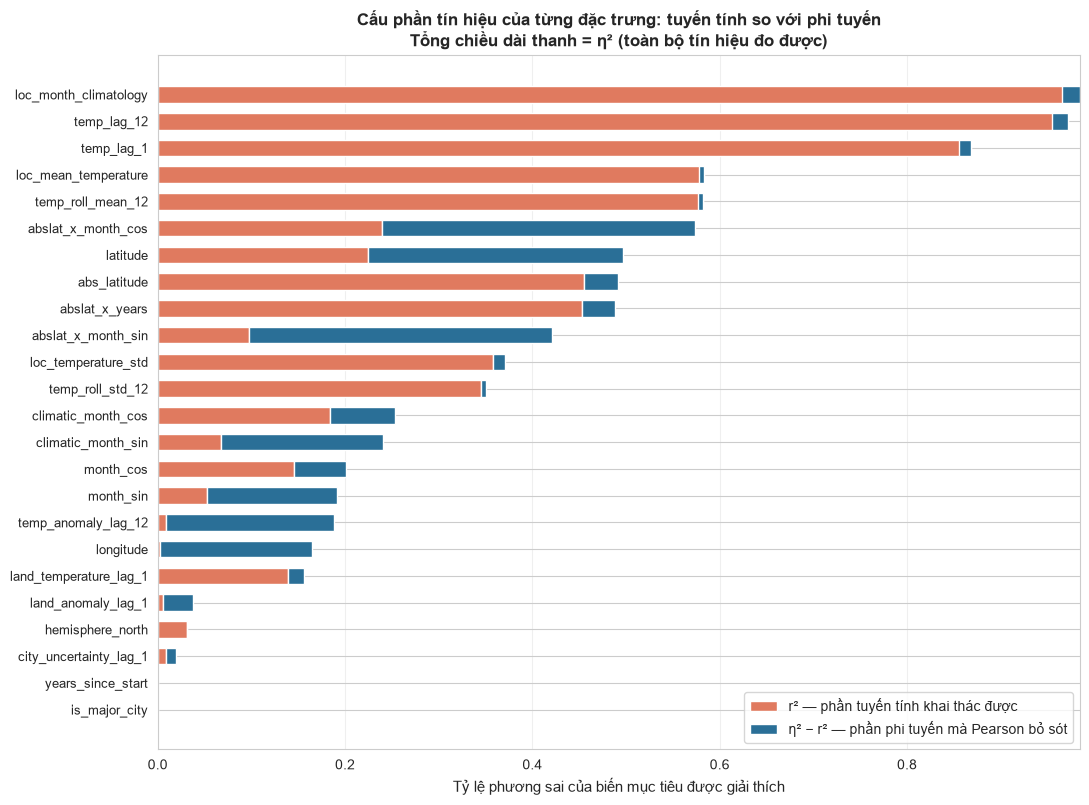

Năm đặc trưng có phần phi tuyến lớn nhất (mô hình tuyến tính khai thác được ít nhất):


,Nhóm,Pearson r,r2,eta2,Phi tuyến (eta2 - r2)
Feature,,,,,
abslat_x_month_cos,Tương tác,-0.4897,0.2398,0.5733,0.3335
abslat_x_month_sin,Tương tác,-0.3122,0.0975,0.4205,0.3230
latitude,Địa lý,-0.4739,0.2246,0.4963,0.2717
temp_anomaly_lag_12,Trễ / Trượt,-0.0946,0.0090,0.1881,0.1792
climatic_month_sin,Thời gian,-0.2589,0.0670,0.2410,0.1740


In [25]:
plot_metrics = feature_metrics.dropna(subset=['eta2']).sort_values('eta2')

fig, ax = plt.subplots(figsize=(11, max(6, len(plot_metrics) * 0.34)))
y_positions = np.arange(len(plot_metrics))

# r² là phần mô hình tuyến tính khai thác được; phần còn lại tới η² là phi tuyến.
ax.barh(y_positions, plot_metrics['r2'], height=0.62,
        color='#e07a5f', label='r² — phần tuyến tính khai thác được')
ax.barh(y_positions, plot_metrics['eta2'] - plot_metrics['r2'], height=0.62,
        left=plot_metrics['r2'], color='#2a6f97',
        label='η² − r² — phần phi tuyến mà Pearson bỏ sót')

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_metrics.index, fontsize=9)
ax.set_xlabel('Tỷ lệ phương sai của biến mục tiêu được giải thích', fontsize=11)
ax.set_title('Cấu phần tín hiệu của từng đặc trưng: tuyến tính so với phi tuyến\n'
             'Tổng chiều dài thanh = η² (toàn bộ tín hiệu đo được)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '08_feature_signal_comparison.png', dpi=200,
            bbox_inches='tight')
print('Đã lưu: reports/images/08_feature_signal_comparison.png')
plt.show()

print('Năm đặc trưng có phần phi tuyến lớn nhất '
      '(mô hình tuyến tính khai thác được ít nhất):')
display(
    feature_metrics.nlargest(5, 'Phi tuyến (eta2 - r2)')[
        ['Nhóm', 'Pearson r', 'r2', 'eta2', 'Phi tuyến (eta2 - r2)']
    ]
)

Mỗi thanh trên biểu đồ được chia thành hai phần: phần cam là `r²` — lượng tín hiệu mà một mô hình tuyến tính khai thác được; phần xanh là `η² − r²` — lượng tín hiệu chỉ mô hình phi tuyến mới lấy được.

Đây là kết luận có ý nghĩa trực tiếp cho Notebook 06: nếu phần xanh chiếm tỷ trọng lớn ở nhiều đặc trưng quan trọng, thì hồi quy tuyến tính (Linear Regression, Ridge, Lasso) sẽ **thua rõ rệt** so với các mô hình dạng cây (Decision Tree, Random Forest, Gradient Boosting) — và đó là điều cần được kiểm chứng bằng số liệu ở Notebook 06 thay vì phỏng đoán trước.

### 6.3. Bàn giao Feature Importance sang Notebook 06


Feature Importance chỉ có ý nghĩa sau khi một mô hình cụ thể đã được huấn luyện bằng train và đánh giá đúng trên validation. Vì vậy Notebook 05 không fit Random Forest và không in R² in-sample tại đây.

Notebook 05 chỉ bàn giao danh sách feature đã chọn cùng metadata. Notebook 06 sẽ tính hệ số chuẩn hóa của Linear Regression, importance của Random Forest/XGBoost và các biểu đồ tương ứng sau khi pipeline preprocessing đã được fit đúng phạm vi.


In [26]:
feature_importance_handoff = pd.DataFrame(
    {
        'Nội dung': [
            'Linear Regression coefficient',
            'Random Forest feature importance',
            'XGBoost feature importance',
            'SHAP (nếu thực hiện)',
        ],
        'Notebook thực hiện': ['06', '06', '06', '06'],
        'Điều kiện': [
            'Fit scaler và mô hình chỉ trên train',
            'Fit mô hình chỉ trên train; đánh giá trên validation',
            'Fit mô hình chỉ trên train; đánh giá trên validation',
            'Giải thích mô hình đã được chọn, không dùng để mở test sớm',
        ],
    }
)
display(feature_importance_handoff)
print('Notebook 05 không huấn luyện mô hình và không tính R².')


,Nội dung,Notebook thực hiện,Điều kiện
0,Linear Regression coefficient,06,Fit scaler và mô hình chỉ trên train
1,Random Forest feature importance,06,Fit mô hình chỉ trên train; đánh giá trên vali...
2,XGBoost feature importance,06,Fit mô hình chỉ trên train; đánh giá trên vali...
3,SHAP (nếu thực hiện),06,"Giải thích mô hình đã được chọn, không dùng để..."


Notebook 05 không huấn luyện mô hình và không tính R².


Việc chuyển bước này sang Notebook 06 loại bỏ hai nguồn gây hiểu nhầm: R² tính trên chính mẫu vừa fit và importance được tính trước khi preprocessing/model contract được khóa. Notebook 05 vẫn đủ căn cứ chọn feature nhờ kiểm tra availability, Pearson, Spearman, η² và đa cộng tuyến trên cửa sổ train riêng.


### 6.4. Kiểm tra đa cộng tuyến giữa các đặc trưng

Quá trình tạo feature có thể sinh các cặp gần như trùng thông tin. Ma trận tương quan dưới đây chỉ sử dụng **toàn bộ train đến năm 1983**, tuyệt đối không đọc validation/test.

Cửa sổ train dài giúp tránh tương quan giả do một biến xu hướng gần như hằng số trong một khoảng ngắn. Bảng đồng thời đối chiếu tương quan trên riêng cửa sổ feature-selection 1974–1983 với toàn train để giải thích các cặp thay đổi mạnh theo độ rộng thời gian.


In [27]:
# Đo đa cộng tuyến trên train đủ rộng; validation/test không tham gia.
redundancy_columns = CANDIDATE_FEATURES + ['year']
redundancy_positions = np.flatnonzero(feature_fit_mask.to_numpy())
if len(redundancy_positions) > REDUNDANCY_SAMPLE_ROWS:
    redundancy_rng = np.random.default_rng(RANDOM_SEED)
    redundancy_positions = np.sort(
        redundancy_rng.choice(
            redundancy_positions, size=REDUNDANCY_SAMPLE_ROWS, replace=False
        )
    )
redundancy_df = feature_df.iloc[redundancy_positions][redundancy_columns]

if (redundancy_df['year'] > FEATURE_FIT_CUTOFF_YEAR).any():
    raise RuntimeError('Mẫu đo trùng lặp chứa dữ liệu ngoài train.')


def feature_pair_correlation(frame: pd.DataFrame) -> pd.Series:
    """Pearson r của mọi cặp feature ứng viên, dạng Series MultiIndex."""
    matrix = frame[CANDIDATE_FEATURES].corr()
    pairs = matrix.where(np.triu(np.ones(matrix.shape), k=1).astype(bool)).stack()
    pairs.index.names = ['Feature A', 'Feature B']
    return pairs.dropna()


wide_window_r = feature_pair_correlation(redundancy_df)
selection_window_r = feature_pair_correlation(eval_df)

redundant_pairs = (
    wide_window_r[wide_window_r.abs() > REDUNDANCY_THRESHOLD]
    .rename('Pearson r')
    .reset_index()
)
redundant_pairs['|r|'] = redundant_pairs['Pearson r'].abs()
redundant_pairs = redundant_pairs.sort_values(
    '|r|', ascending=False
).reset_index(drop=True)

flagged_pairs = wide_window_r[
    wide_window_r.abs() > REDUNDANCY_THRESHOLD
].index.union(
    selection_window_r[selection_window_r.abs() > REDUNDANCY_THRESHOLD].index
)
window_comparison = pd.DataFrame(
    {
        'r (feature-selection)': selection_window_r.reindex(flagged_pairs),
        'r (toàn train)': wide_window_r.reindex(flagged_pairs),
    }
)
window_comparison['Kết luận'] = np.where(
    window_comparison['r (toàn train)'].abs() > REDUNDANCY_THRESHOLD,
    'Trùng lặp bền vững',
    'Trùng lặp do cửa sổ hẹp',
)

print(f'Cửa sổ đo chính      : {int(redundancy_df["year"].min())}-'
      f'{int(redundancy_df["year"].max())} · {len(redundancy_df):,} dòng train')
print(f'Ngưỡng trùng lặp     : |r| > {REDUNDANCY_THRESHOLD}')
print(f'Số cặp vượt ngưỡng   : {len(redundant_pairs)}')
print('Validation/test được sử dụng: 0 dòng')
display(
    window_comparison.sort_values(
        'r (toàn train)', key=lambda values: values.abs(), ascending=False
    )
)


Cửa sổ đo chính      : 1863-1983 · 500,000 dòng train
Ngưỡng trùng lặp     : |r| > 0.95
Số cặp vượt ngưỡng   : 3
Validation/test được sử dụng: 0 dòng


,,r (feature-selection),r (toàn train),Kết luận
Feature A,Feature B,,,
loc_mean_temperature,temp_roll_mean_12,0.9980,0.9979,Trùng lặp bền vững
loc_month_climatology,temp_lag_12,0.9926,0.9932,Trùng lặp bền vững
loc_temperature_std,temp_roll_std_12,0.9918,0.9928,Trùng lặp bền vững
abs_latitude,abslat_x_years,0.9985,0.6066,Trùng lặp do cửa sổ hẹp


Các cặp `Trùng lặp bền vững` giữ `|r|` cao trên toàn train và được chuyển sang quy tắc lược bỏ ở Mục 7. Các cặp chỉ cao trong cửa sổ 10 năm không bị loại tự động vì có thể là tương quan giả do biến thời gian chưa đủ độ biến thiên.

Toàn bộ phép tính chỉ dùng feature trong train, không dùng target để đo tương quan cặp và không sử dụng validation/test.


### 6.5. Kiểm tra rò rỉ dữ liệu

Mục này thực hiện bốn nhóm kiểm tra:

1. Đo lại mức tương quan của các cột nhiệt độ cùng tháng bị loại.
2. Xác minh `temp_lag_12` đúng là target của cùng vị trí tại `t − 12`.
3. Xác minh target statistics trong train được xây dựng theo quá khứ tích lũy và dòng đầu nhóm không có climatology giả tạo.
4. Xác minh candidate feature không chứa dữ liệu cùng kỳ/target-derived; mẫu chọn feature chỉ nằm trong train 1974–1983 và không chứa validation/test.


In [28]:
# --- Phép thử 1: mức tương quan của các cột bị loại --------------------
leakage_candidates = ['major_city_average_temperature', 'country_average_temperature']
leakage_rows = []
for column in leakage_candidates:
    valid = eval_df[column].notna() & eval_target.notna()
    leakage_rows.append(
        {
            'Cột nguồn': column,
            'Số dòng có giá trị': int(valid.sum()),
            'Tỷ lệ có giá trị': float(valid.mean()),
            'Pearson r với target': float(eval_df.loc[valid, column].corr(eval_target[valid]))
            if valid.sum() > 1 else float('nan'),
        }
    )
display(pd.DataFrame(leakage_rows).set_index('Cột nguồn'))
print('→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố '
      'đang dự báo, nên không được dùng làm đặc trưng.')

,Số dòng có giá trị,Tỷ lệ có giá trị,Pearson r với target
Cột nguồn,,,
major_city_average_temperature,10200,0.0273,1.0000
country_average_temperature,374280,1.0000,0.8962


→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố đang dự báo, nên không được dùng làm đặc trưng.


In [29]:
# --- Phép thử 2: temp_lag_12 phải khớp target của 12 tháng trước -------
check_frame = feature_df[['location_key', TARGET_COLUMN, 'temp_lag_12']]
verify_pool = check_frame[check_frame['temp_lag_12'].notna()]
verify_size = min(5_000, len(verify_pool))
verify_sample = verify_pool.sample(n=verify_size, random_state=RANDOM_SEED)

truth_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(), index=feature_df['location_key'].to_numpy()
)
expected_lag = truth_lookup.reindex(verify_sample['location_key'].to_numpy() - 12).to_numpy()
lag_matches = np.allclose(
    verify_sample['temp_lag_12'].to_numpy(dtype='float64'),
    expected_lag.astype('float64'),
    equal_nan=True,
)

print(f'Kiểm tra {verify_size:,} dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước '
      f'→ {"PASS" if lag_matches else "FAIL"}')
if not lag_matches:
    raise RuntimeError('temp_lag_12 không khớp giá trị quá khứ; đặc trưng trễ bị sai mốc.')

# Không đặc trưng trễ nào được trùng chính target của cùng tháng.
same_month_leak = [
    name for name in ('temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12')
    if np.isclose(
        feature_df[name].corr(feature_df[TARGET_COLUMN]), 1.0, atol=1e-6
    )
]
print(f'Đặc trưng trễ trùng khớp target: {same_month_leak or "không có"}')

Kiểm tra 5,000 dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước → PASS
Đặc trưng trễ trùng khớp target: không có


In [30]:
# --- Phép thử 3: provenance, thời gian và phạm vi chọn feature ----------
LEAKAGE_CORRELATION_LIMIT = 0.999
suspicious = feature_metrics[feature_metrics['|Pearson|'] > LEAKAGE_CORRELATION_LIMIT]
if not suspicious.empty:
    display(suspicious)
    raise RuntimeError('Có feature gần như trùng khớp hoàn toàn với target.')

forbidden_same_month_features = {
    'major_city_average_temperature',
    'country_average_temperature',
    'land_average_temperature',
    'city_average_temperature_uncertainty',
    'temp_anomaly_vs_climatology',
}
forbidden_candidates = forbidden_same_month_features.intersection(CANDIDATE_FEATURES)
if forbidden_candidates:
    raise RuntimeError(
        f'Candidate feature chứa dữ liệu cùng kỳ/target-derived: {forbidden_candidates}'
    )

# Nhóm (location, month) chưa có quan sát quá khứ phải có raw climatology NaN.
first_loc_month_rows = fit_loc_month_past_count == 0
if np.isfinite(fit_raw_loc_month_climatology[first_loc_month_rows]).any():
    raise RuntimeError('Climatology train đã dùng dữ liệu không thuộc quá khứ.')

if not eval_df['year'].between(
    FEATURE_SELECTION_START_YEAR, FEATURE_FIT_CUTOFF_YEAR
).all():
    raise RuntimeError('Mẫu chọn feature nằm ngoài cửa sổ train đã quy định.')
if validation_period_mask.loc[eval_df.index].any() or test_period_mask.loc[eval_df.index].any():
    raise RuntimeError('Validation/test đã lọt vào bước chọn feature.')

print(f'PASS: không feature nào có |r| > {LEAKAGE_CORRELATION_LIMIT}.')
print('PASS: không có dữ liệu cùng kỳ hoặc feature suy ra trực tiếp từ target.')
print('PASS: target statistics của train dùng expanding past-only.')
print('PASS: chọn feature chỉ dùng train 1974–1983; validation/test chưa được mở.')


PASS: không feature nào có |r| > 0.999.
PASS: không có dữ liệu cùng kỳ hoặc feature suy ra trực tiếp từ target.
PASS: target statistics của train dùng expanding past-only.
PASS: chọn feature chỉ dùng train 1974–1983; validation/test chưa được mở.


Các dòng `PASS` kiểm tra cả nguồn gốc feature, thứ tự thời gian và ranh giới tập dữ liệu. Tương quan thấp không tự chứng minh không leakage; vì vậy kiểm tra quan trọng nhất là provenance của từng feature và điều kiện past-only được xác minh riêng.


### 6.6. Bàn giao SHAP sang Notebook 06


SHAP giải thích đóng góp của feature cho một mô hình đã huấn luyện. Notebook 05 chưa có mô hình cuối nên không chạy SHAP. Notebook 06 có thể thực hiện SHAP sau khi chọn mô hình bằng validation; test không được dùng để chọn mẫu giải thích hoặc điều chỉnh mô hình.


In [31]:
print('SHAP được chuyển sang Notebook 06 sau bước huấn luyện và chọn mô hình.')
print('Notebook 05 không import shap và không fit thêm mô hình tại mục này.')


SHAP được chuyển sang Notebook 06 sau bước huấn luyện và chọn mô hình.
Notebook 05 không import shap và không fit thêm mô hình tại mục này.


## 7. Lựa chọn Feature

### 7.1. Bộ quy tắc lựa chọn

Việc giữ hay loại được quyết định bằng bộ quy tắc định lượng công khai:

1. Giữ bắt buộc các cặp mã hóa chu kỳ và `years_since_start` vì ý nghĩa nghiệp vụ.
2. Loại cột hằng số trong cửa sổ feature-selection.
3. Loại khi đồng thời `eta2 < 0.005` và `|Pearson| < 0.05` trên train 1974–1983.
4. Với cặp `|r| > 0.95` đo trên toàn train đến 1983, giữ feature có `eta2` cao hơn và loại feature còn lại.
5. Giữ các trường hợp còn lại.

Validation 1984–1993 và test 1994–2013 không tham gia bất kỳ quy tắc nào. Các cột bị loại vì lý do ngữ nghĩa được ghi riêng tại Mục 7.3.


In [38]:
selection_records = {
    name: {'decision': 'Giữ', 'reason': 'Đạt ngưỡng tín hiệu và không trùng lặp.'}
    for name in CANDIDATE_FEATURES
}

# --- Quy tắc 1 và 2: giữ bắt buộc, cột hằng số, tín hiệu quá yếu -------
for name in CANDIDATE_FEATURES:
    if FEATURE_CATALOG[name]['force_keep']:
        selection_records[name] = {
            'decision': 'Giữ',
            'reason': f"Giữ bắt buộc. {FEATURE_CATALOG[name]['keep_reason']}",
        }
        continue

    # Cột hằng số (hoặc toàn NaN) không có phương sai nên mọi chỉ số đều là NaN.
    if eval_df[name].nunique(dropna=True) < 2:
        selection_records[name] = {
            'decision': 'Loại',
            'reason': 'Cột hằng số trên dữ liệu hiện tại nên không mang thông tin phân biệt.',
        }
        continue

    eta = feature_metrics.loc[name, 'eta2']
    abs_pearson = feature_metrics.loc[name, '|Pearson|']
    eta_weak = not (eta == eta) or eta < MIN_ETA_SQUARED
    pearson_weak = not (abs_pearson == abs_pearson) or abs_pearson < MIN_ABS_PEARSON
    if eta_weak and pearson_weak:
        selection_records[name] = {
            'decision': 'Loại',
            'reason': f'Tín hiệu quá yếu (η²={eta:.4f} < {MIN_ETA_SQUARED}, '
                      f'|r|={abs_pearson:.4f} < {MIN_ABS_PEARSON}).',
        }

# --- Quy tắc 3: trùng lặp thông tin ------------------------------------
for _, pair in redundant_pairs.iterrows():
    first, second = pair['Feature A'], pair['Feature B']
    if selection_records[first]['decision'] == 'Loại' or selection_records[second]['decision'] == 'Loại':
        continue
    first_eta = feature_metrics.loc[first, 'eta2']
    second_eta = feature_metrics.loc[second, 'eta2']
    weaker = first if (second_eta > first_eta or not (first_eta == first_eta)) else second
    stronger = second if weaker == first else first
    if FEATURE_CATALOG[weaker]['force_keep']:
        continue
    selection_records[weaker] = {
        'decision': 'Loại',
        'reason': f'Trùng lặp thông tin với {stronger} (r={pair["Pearson r"]:.4f}); '
                  f'{stronger} có η² cao hơn.',
    }

SELECTED_FEATURES = [
    name for name in CANDIDATE_FEATURES if selection_records[name]['decision'] == 'Giữ'
]
DROPPED_FEATURES = [
    name for name in CANDIDATE_FEATURES if selection_records[name]['decision'] == 'Loại'
]

print(f'Đặc trưng ứng viên : {len(CANDIDATE_FEATURES)}')
print(f'Giữ lại            : {len(SELECTED_FEATURES)}')
print(f'Loại bỏ            : {len(DROPPED_FEATURES)}')

Đặc trưng ứng viên : 25
Giữ lại            : 20
Loại bỏ            : 5


### 7.2. Bảng quyết định giữ / loại

In [39]:
decision_table = feature_metrics.join(
    pd.DataFrame(
        [
            {
                'Feature': name,
                'Khả dụng': FEATURE_CATALOG[name]['availability'],
                'Kết quả': selection_records[name]['decision'],
                'Lý do': selection_records[name]['reason'],
            }
            for name in CANDIDATE_FEATURES
        ]
    ).set_index('Feature')
)
decision_table = decision_table[
    ['Nhóm', 'Khả dụng', 'Pearson r', 'r2', 'Spearman', 'eta2', 'Kết quả', 'Lý do']
].sort_values(['Kết quả', 'eta2'], ascending=[True, False])

display(decision_table)
display(
    decision_table.groupby(['Nhóm', 'Kết quả'], observed=True)
    .size()
    .unstack(fill_value=0)
)

,Nhóm,Khả dụng,Pearson r,r2,Spearman,eta2,Kết quả,Lý do
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,fit_stat,0.9923,0.9846,0.9930,0.9658,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
temp_lag_1,Trễ / Trượt,history,0.9320,0.8686,0.9351,0.8551,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
loc_mean_temperature,Khí hậu theo vị trí,fit_stat,0.7636,0.5830,0.7909,0.5781,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abslat_x_month_cos,Tương tác,static,-0.4897,0.2398,-0.4181,0.5733,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
latitude,Địa lý,static,-0.4739,0.2246,-0.5906,0.4963,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abs_latitude,Địa lý,static,-0.6744,0.4549,-0.7097,0.4917,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abslat_x_years,Tương tác,static,-0.6729,0.4529,-0.7080,0.4879,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abslat_x_month_sin,Tương tác,static,-0.3122,0.0975,-0.2858,0.4205,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
loc_temperature_std,Khí hậu theo vị trí,fit_stat,-0.5983,0.3579,-0.5764,0.3710,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.


Kết quả,Giữ,Loại
Nhóm,,
Bối cảnh toàn cầu,2,0
Chất lượng dữ liệu,1,0
Khí hậu theo vị trí,3,1
Thời gian,5,0
Trễ / Trượt,2,3
Tương tác,3,0
Địa lý,4,1


Bảng này là sản phẩm chính của Mục 7: mỗi đặc trưng đều có số liệu kèm lý do giữ hoặc loại, thể hiện tư duy chọn lọc thay vì giữ lại tất cả. Bảng chéo phía dưới cho biết nhóm nào đóng góp nhiều đặc trưng hữu ích nhất và nhóm nào gần như bị loại hết — thông tin đáng đưa vào báo cáo cuối.

### 7.3. Các cột bị loại vì lý do ngữ nghĩa

Ngoài các đặc trưng bị bộ quy tắc loại, một số cột của bảng sạch bị loại vì lý do bản chất chứ không vì số liệu yếu. Nhiều cột trong đó thậm chí không được đọc vào bộ nhớ ở Mục 3.2.

In [40]:
SEMANTIC_EXCLUSIONS = [
    {
        'Cột': 'major_city_average_temperature',
        'Lý do loại': 'Rò rỉ trực tiếp: phép đo cùng tháng trùng target khi có giá trị.',
    },
    {
        'Cột': 'country_average_temperature',
        'Lý do loại': 'Nhiệt độ quốc gia cùng tháng và đã chứa thông tin thành phố cần dự báo.',
    },
    {
        'Cột': 'land_average_temperature (cùng tháng)',
        'Lý do loại': 'Không có sẵn khi dự báo tương lai; thay bằng land_temperature_lag_1.',
    },
    {
        'Cột': 'city_average_temperature_uncertainty (cùng tháng)',
        'Lý do loại': 'Chỉ xuất hiện cùng phép đo target; thay bằng city_uncertainty_lag_1.',
    },
    {
        'Cột': 'land_max/min/land_and_ocean_temperature',
        'Lý do loại': 'Đều là bối cảnh cùng tháng, không phù hợp kịch bản dự báo một bước.',
    },
    {
        'Cột': 'month / quarter / decade (dạng số nguyên thô)',
        'Lý do loại': 'Quan hệ tuần hoàn được biểu diễn bằng sin/cos và xu hướng thời gian.',
    },
    {
        'Cột': 'city_temperature_iqr_outlier',
        'Lý do loại': 'Cờ phân tích chất lượng, không phải thông tin có sẵn khi dự báo.',
    },
    {
        'Cột': 'latitude_zone / climatic_season',
        'Lý do loại': 'Chỉ dùng phân tích; thông tin đã có trong latitude và mã hóa chu kỳ.',
    },
    {
        'Cột': 'temp_anomaly_vs_climatology',
        'Lý do loại': 'Suy ra trực tiếp từ target, chỉ dùng cho insight ở Mục 8.',
    },
]
display(pd.DataFrame(SEMANTIC_EXCLUSIONS).set_index('Cột'))

print('Danh sách đặc trưng cuối cùng:')
for index, name in enumerate(SELECTED_FEATURES, start=1):
    meta = FEATURE_CATALOG[name]
    print(f'  {index:2d}. {name:30s} [{meta["group"]} · {meta["availability"]}]')


,Lý do loại
Cột,
major_city_average_temperature,Rò rỉ trực tiếp: phép đo cùng tháng trùng targ...
country_average_temperature,Nhiệt độ quốc gia cùng tháng và đã chứa thông ...
land_average_temperature (cùng tháng),Không có sẵn khi dự báo tương lai; thay bằng l...
city_average_temperature_uncertainty (cùng tháng),Chỉ xuất hiện cùng phép đo target; thay bằng c...
land_max/min/land_and_ocean_temperature,"Đều là bối cảnh cùng tháng, không phù hợp kịch..."
month / quarter / decade (dạng số nguyên thô),Quan hệ tuần hoàn được biểu diễn bằng sin/cos ...
city_temperature_iqr_outlier,"Cờ phân tích chất lượng, không phải thông tin ..."
latitude_zone / climatic_season,Chỉ dùng phân tích; thông tin đã có trong lati...
temp_anomaly_vs_climatology,"Suy ra trực tiếp từ target, chỉ dùng cho insig..."


Danh sách đặc trưng cuối cùng:
   1. month_sin                      [Thời gian · static]
   2. month_cos                      [Thời gian · static]
   3. climatic_month_sin             [Thời gian · static]
   4. climatic_month_cos             [Thời gian · static]
   5. years_since_start              [Thời gian · static]
   6. latitude                       [Địa lý · static]
   7. abs_latitude                   [Địa lý · static]
   8. hemisphere_north               [Địa lý · static]
   9. longitude                      [Địa lý · static]
  10. abslat_x_month_sin             [Tương tác · static]
  11. abslat_x_month_cos             [Tương tác · static]
  12. abslat_x_years                 [Tương tác · static]
  13. loc_month_climatology          [Khí hậu theo vị trí · fit_stat]
  14. loc_mean_temperature           [Khí hậu theo vị trí · fit_stat]
  15. loc_temperature_std            [Khí hậu theo vị trí · fit_stat]
  16. temp_lag_1                     [Trễ / Trượt · history]
  17. temp_ano

Danh sách in ra chính là thứ tự đặc trưng sẽ được ghi vào `feature_metadata.json` ở Mục 9.3. Notebook 06 phải đọc đúng danh sách và đúng thứ tự này, vì mô hình sau khi huấn luyện chỉ nhận đầu vào theo một thứ tự cột cố định.

## 8. Insight mới từ tập đặc trưng

Mục insight chỉ dùng **train đến năm 1983**. `temp_anomaly_vs_climatology` được suy ra từ target nên tuyệt đối không phải candidate feature; nó chỉ mô tả xu hướng sau khi điều chỉnh mùa vụ và vị trí.

Giới hạn insight ở train giúp Notebook 05 không nhìn target của validation/test trước khi Notebook 06 chọn và đánh giá mô hình.


Đã lưu: reports/images/10_anomaly_by_latitude_zone.png


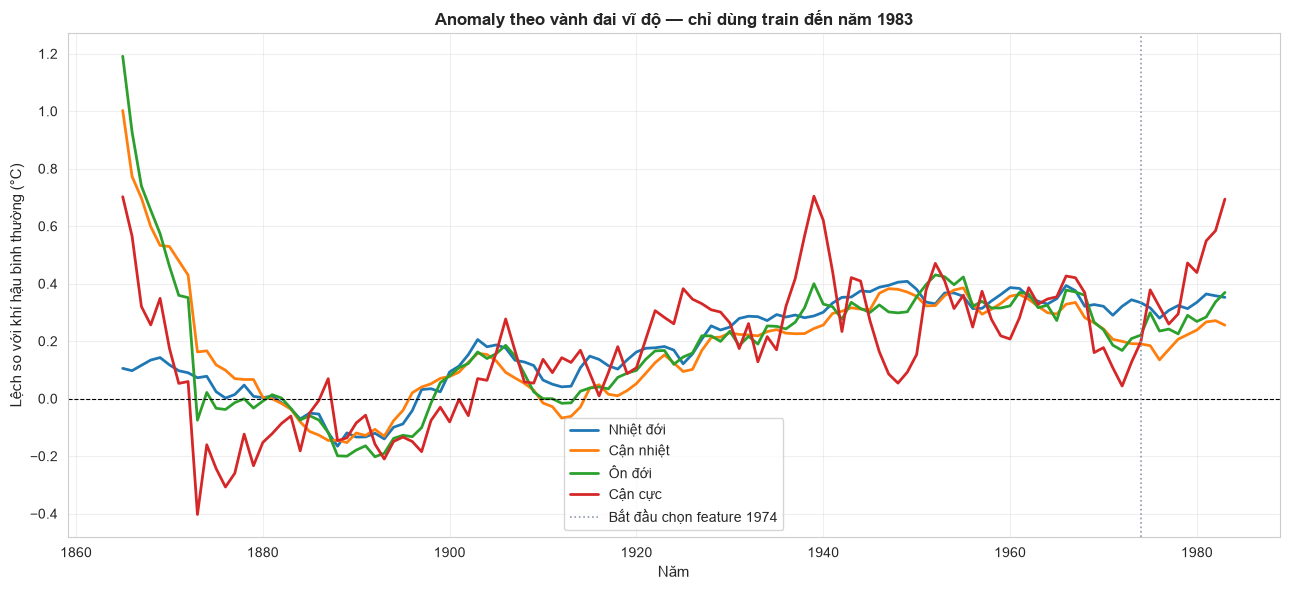

In [41]:
insight_df = feature_df.loc[feature_fit_mask].copy()
insight_df['temp_anomaly_vs_climatology'] = (
    insight_df[TARGET_COLUMN] - insight_df['loc_month_climatology']
).astype('float32')

anomaly_by_zone_year = (
    insight_df.groupby(['latitude_zone', 'year'], observed=True)[
        'temp_anomaly_vs_climatology'
    ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
for zone, zone_data in anomaly_by_zone_year.groupby('latitude_zone', observed=True):
    smoothed = zone_data.set_index('year')['temp_anomaly_vs_climatology'].rolling(
        10, min_periods=3
    ).mean()
    ax.plot(smoothed.index, smoothed.to_numpy(), linewidth=2, label=str(zone))

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(
    FEATURE_SELECTION_START_YEAR, color='#8d99ae', linewidth=1.2,
    linestyle=':', label=f'Bắt đầu chọn feature {FEATURE_SELECTION_START_YEAR}',
)
ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('Lệch so với khí hậu bình thường (°C)', fontsize=11)
ax.set_title(
    'Anomaly theo vành đai vĩ độ — chỉ dùng train đến năm 1983',
    fontsize=12, fontweight='bold',
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    REPORT_IMAGES_DIR / '10_anomaly_by_latitude_zone.png',
    dpi=200, bbox_inches='tight',
)
print('Đã lưu: reports/images/10_anomaly_by_latitude_zone.png')
plt.show()


In [42]:
def warming_rate(group: pd.DataFrame) -> float:
    """Độ dốc °C/năm của anomaly trung bình theo năm."""
    if len(group) < 10:
        return float('nan')
    slope, _ = np.polyfit(
        group['year'].to_numpy(dtype='float64'),
        group['temp_anomaly_vs_climatology'].to_numpy(dtype='float64'),
        1,
    )
    return float(slope)


warming_by_zone = (
    anomaly_by_zone_year.groupby('latitude_zone', observed=True)[
        ['year', 'temp_anomaly_vs_climatology']
    ]
    .apply(warming_rate)
    .sort_values(ascending=False)
    .to_frame('Tốc độ ấm lên trong train (°C/năm)')
    .rename_axis('Vành đai vĩ độ')
)
warming_by_zone['Trên 100 năm (°C)'] = (
    warming_by_zone['Tốc độ ấm lên trong train (°C/năm)'] * 100
)
display(warming_by_zone)

overall_slope = warming_rate(
    insight_df.groupby('year', observed=True)['temp_anomaly_vs_climatology']
    .mean()
    .reset_index()
)
print(f'Tốc độ anomaly trên train đến {FEATURE_FIT_CUTOFF_YEAR}: '
      f'{overall_slope:.4f}°C/năm')
print('Validation/test chưa được dùng trong insight này.')


,Tốc độ ấm lên trong train (°C/năm),Trên 100 năm (°C)
Vành đai vĩ độ,,
Cận cực,0.0051,0.5063
Nhiệt đới,0.0040,0.4046
Ôn đới,0.0028,0.2776
Cận nhiệt,0.0019,0.1917


Tốc độ anomaly trên train đến 1983: 0.0029°C/năm
Validation/test chưa được dùng trong insight này.


Kết quả chỉ mô tả giai đoạn train và không được diễn giải là hiệu quả dự báo. `temp_anomaly_vs_climatology` không xuất sang Notebook 06. Validation/test vẫn còn nguyên cho quy trình chọn và đánh giá mô hình.


## 9. Lưu dữ liệu mới

### 9.1. Chuẩn bị bảng đầu ra

Bảng đầu ra gồm khóa nghiệp vụ, `year`/`month`, target, feature đã chọn và nhãn `data_split`.

Không lưu feature bị loại, cột suy ra từ target, phép đo cùng tháng không có sẵn lúc dự báo hoặc khóa kỹ thuật tạm. `data_split` có ba giá trị `train`, `validation`, `test`; Notebook 06 phải dùng nhãn này thay vì chia ngẫu nhiên. `is_train_period` được giữ để tương thích và bằng 1 cho train + validation.


In [43]:
OUTPUT_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
    'year', 'month',
]

feature_df['data_split'] = np.select(
    [feature_fit_mask, validation_period_mask, test_period_mask],
    ['train', 'validation', 'test'],
    default='unassigned',
)
feature_df['is_train_period'] = train_period_mask.astype('int8')

output_columns = (
    OUTPUT_KEY_COLUMNS
    + [TARGET_COLUMN]
    + [name for name in SELECTED_FEATURES if name not in OUTPUT_KEY_COLUMNS]
    + ['data_split', 'is_train_period']
)
output_df = feature_df[output_columns]

forbidden_output_columns = {
    'temp_anomaly_vs_climatology',
    'major_city_average_temperature',
    'country_average_temperature',
    'land_average_temperature',
    'city_average_temperature_uncertainty',
}
leaked = forbidden_output_columns.intersection(output_df.columns)
if leaked:
    raise RuntimeError(f'Bảng đầu ra chứa cột không hợp lệ: {sorted(leaked)}')
if (feature_df['data_split'] == 'unassigned').any():
    raise RuntimeError('Có dòng chưa được gán data_split.')

print(f'Bảng đầu ra: {len(output_df):,} dòng × {output_df.shape[1]} cột')
print(f'Bộ nhớ      : {output_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
display(output_df.head())
display(output_df['data_split'].value_counts().to_frame('Số dòng'))
print('PASS: bảng đầu ra không chứa dữ liệu cùng kỳ hoặc feature suy ra từ target.')


Bảng đầu ra: 5,579,085 dòng × 28 cột
Bộ nhớ      : 722.2 MB


,observation_date,city_name,country_name,latitude,longitude,year,month,city_average_temperature,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,abs_latitude,hemisphere_north,abslat_x_month_sin,abslat_x_month_cos,abslat_x_years,loc_month_climatology,loc_mean_temperature,loc_temperature_std,temp_lag_1,temp_anomaly_lag_12,land_temperature_lag_1,land_anomaly_lag_1,city_uncertainty_lag_1,data_split,is_train_period
0,1863-01-01,A Coruña,Spain,42.5900,-8.7300,1863,1,8.1310,0.5000,0.8660,0.5000,0.8660,0,42.5900,1,21.2950,36.8840,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1
1,1863-02-01,A Coruña,Spain,42.5900,-8.7300,1863,2,8.7000,0.8660,0.5000,0.8660,0.5000,0,42.5900,1,36.8840,21.2950,0.0000,8.1310,8.1310,NaN,8.1310,NaN,3.0340,NaN,2.4300,train,1
2,1863-03-01,A Coruña,Spain,42.5900,-8.7300,1863,3,9.9850,1.0000,-0.0000,1.0000,-0.0000,0,42.5900,1,42.5900,-0.0000,0.0000,8.4155,8.4155,0.4024,8.7000,NaN,3.2530,NaN,2.7820,train,1
3,1863-04-01,A Coruña,Spain,42.5900,-8.7300,1863,4,12.6010,0.8660,-0.5000,0.8660,-0.5000,0,42.5900,1,36.8840,-21.2950,0.0000,8.9387,8.9387,0.9498,9.9850,NaN,4.6820,NaN,0.7800,train,1
4,1863-05-01,A Coruña,Spain,42.5900,-8.7300,1863,5,13.2300,0.5000,-0.8660,0.5000,-0.8660,0,42.5900,1,21.2950,-36.8840,0.0000,9.8542,9.8542,1.9886,12.6010,NaN,7.9310,NaN,1.2260,train,1


,Số dòng
data_split,
train,4468327
test,736478
validation,374280


PASS: bảng đầu ra không chứa dữ liệu cùng kỳ hoặc feature suy ra từ target.


### 9.2. Kiểm tra dung lượng và ghi file

Bảng đầu ra có hơn 5,5 triệu dòng nên file kết quả rất lớn: dạng CSV thô khoảng 1,3 GB, còn nén gzip chỉ khoảng 200–300 MB. Vì `data/processed/` đã chứa vài file dung lượng lớn từ các notebook trước, notebook **ước lượng và kiểm tra dung lượng trống trước khi ghi**, thay vì để thao tác ghi làm đầy ổ đĩa rồi thất bại giữa chừng.

Mặc định `OUTPUT_COMPRESSION = 'gzip'`. `pandas.read_csv()` đọc file `.csv.gz` trong suốt nên Notebook 06 không cần xử lý gì thêm. Nếu cần file `.csv` thô, đặt `OUTPUT_COMPRESSION = None` ở Mục 2.3 — với điều kiện còn đủ chỗ trống.

In [44]:
BYTES_PER_VALUE = 9          # ước lượng độ dài trung bình một giá trị trong CSV
GZIP_RATIO = 0.22            # tỷ lệ nén thực nghiệm với dữ liệu dạng số

raw_estimate = len(output_df) * output_df.shape[1] * BYTES_PER_VALUE
estimated_bytes = raw_estimate * (GZIP_RATIO if OUTPUT_COMPRESSION == 'gzip' else 1.0)
free_bytes = shutil.disk_usage(PROCESSED_DIR).free

print(f'Ước lượng kích thước file : {estimated_bytes / 1024 ** 3:,.2f} GB '
      f'({OUTPUT_COMPRESSION or "không nén"})')
print(f'Dung lượng trống          : {free_bytes / 1024 ** 3:,.2f} GB')

if free_bytes < estimated_bytes * 1.3:
    raise RuntimeError(
        f'Không đủ dung lượng trống để ghi {OUTPUT_PATH.name} '
        f'(cần ~{estimated_bytes * 1.3 / 1024 ** 3:.2f} GB, còn {free_bytes / 1024 ** 3:.2f} GB).\n'
        'Cách xử lý: đặt OUTPUT_COMPRESSION = "gzip" ở Mục 2.3, '
        'hoặc dọn bớt file lớn trong data/processed/.'
    )
print('PASS: đủ dung lượng để ghi file.')

Ước lượng kích thước file : 0.29 GB (gzip)
Dung lượng trống          : 38.53 GB
PASS: đủ dung lượng để ghi file.


In [ ]:
output_df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding='utf-8',
    date_format='%Y-%m-%d',
    float_format='%.4f',
    compression=OUTPUT_COMPRESSION,
)

actual_size_mb = OUTPUT_PATH.stat().st_size / 1024 ** 2
print('Đã lưu:', OUTPUT_PATH)
print(f'Kích thước thực tế: {actual_size_mb:,.1f} MB')

# Đọc lại vài dòng đầu để xác nhận file hợp lệ và đúng thứ tự cột.
verify_df = pd.read_csv(OUTPUT_PATH, nrows=5)
if list(verify_df.columns) != output_columns:
    raise RuntimeError('Thứ tự cột trong file không khớp bảng đầu ra.')
print(f'PASS: đọc lại được {verify_df.shape[1]} cột đúng thứ tự.')
display(verify_df)

`float_format='%.4f'` giới hạn 4 chữ số thập phân: dữ liệu nguồn chỉ có 3 chữ số nên không mất thông tin, mà tránh được việc `float32` in ra hàng chục chữ số vô nghĩa và làm file phình lên.

Bước đọc lại 5 dòng đầu là phép kiểm tra rẻ nhưng hiệu quả: nó xác nhận file ghi thành công, giải nén được và giữ đúng thứ tự cột mà Notebook 06 sẽ dựa vào.

### 9.3. Lưu metadata đặc trưng

Metadata là hợp đồng dữ liệu giữa Notebook 05 và Notebook 06. Ngoài danh sách/thứ tự feature, file ghi rõ cửa sổ feature-selection, ba split modeling, chiến lược `past_only_expanding`, điều kiện availability và cảnh báo năm 2013 chưa đủ tháng.

`feature_statistics.csv.gz` lưu thống kê cố định được chốt từ train đến năm 1983 để tái tạo feature khi suy luận sau mốc train. Notebook 06/07 không được tính lại các thống kê này từ validation hoặc test.


In [ ]:
# Lưu bảng thống kê cần thiết để tái tạo feature fit_stat khi suy luận.
location_reference = (
    feature_df[
        ['location_id', 'city_name', 'country_name', 'latitude', 'longitude',
         'latitude_zone']
    ]
    .drop_duplicates('location_id')
    .copy()
)

fixed_location_stats = location_stats.copy()
fixed_location_stats['loc_mean_temperature'] = (
    fixed_location_stats['total'] / fixed_location_stats['count']
)
fixed_location_stats['loc_temperature_std'] = np.sqrt(
    np.maximum(
        (
            fixed_location_stats['total_sq']
            - fixed_location_stats['total'] ** 2 / fixed_location_stats['count']
        )
        / (fixed_location_stats['count'] - 1),
        0,
    )
)

feature_statistics = (
    loc_month_stats.assign(
        loc_month_climatology=(
            loc_month_stats['sum'] / loc_month_stats['count']
        )
    )
    .reset_index()[['location_id', 'month', 'loc_month_climatology']]
    .merge(location_reference, on='location_id', how='left', validate='many_to_one')
    .merge(
        fixed_location_stats[
            ['loc_mean_temperature', 'loc_temperature_std']
        ].reset_index(),
        on='location_id',
        how='left',
        validate='many_to_one',
    )
)
feature_statistics.to_csv(
    FEATURE_STATS_PATH,
    index=False,
    encoding='utf-8',
    float_format='%.6f',
    compression='gzip',
)

zone_fallback = (
    zone_month_stats['sum'] / zone_month_stats['count']
).to_dict()
global_fallback = (
    global_month_stats['sum'] / global_month_stats['count']
).to_dict()

feature_metadata = {
    'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'created_by': '05_feature_engineering.ipynb',
    'data_source': DATA_SOURCE,
    'forecast_scenario': 'one_month_ahead_with_observed_history',
    'fast_mode': FAST_MODE,
    'row_count': int(len(output_df)),
    'location_count': int(feature_df['location_id'].nunique()),
    'target': TARGET_COLUMN,
    'feature_selection_start_year': int(FEATURE_SELECTION_START_YEAR),
    'feature_fit_cutoff_year': int(FEATURE_FIT_CUTOFF_YEAR),
    'target_statistics_train_strategy': 'past_only_expanding',
    'global_baseline_train_strategy': 'past_only_expanding',
    'validation_start_year': int(VALIDATION_START_YEAR),
    'train_cutoff_year': int(TRAIN_CUTOFF_YEAR),
    'split_counts': {
        str(name): int(count)
        for name, count in output_df['data_split'].value_counts().items()
    },
    'observation_date_range': [
        str(feature_df['observation_date'].min().date()),
        str(feature_df['observation_date'].max().date()),
    ],
    'last_year_is_partial': True,
    'last_observation_date': '2013-09-01',
    'output_file': OUTPUT_PATH.name,
    'feature_statistics_file': FEATURE_STATS_PATH.name,
    'postgres_table': f'public.{FEATURE_TABLE}',
    'key_columns': OUTPUT_KEY_COLUMNS,
    'feature_names': SELECTED_FEATURES,
    'feature_details': {
        name: {
            'group': FEATURE_CATALOG[name]['group'],
            'availability': FEATURE_CATALOG[name]['availability'],
            'description': FEATURE_CATALOG[name]['description'],
            'pearson_r_feature_selection': round(float(feature_metrics.loc[name, 'Pearson r']), 6),
            'eta_squared_feature_selection': round(float(feature_metrics.loc[name, 'eta2']), 6),
        }
        for name in SELECTED_FEATURES
    },
    'dropped_features': {
        name: selection_records[name]['reason'] for name in DROPPED_FEATURES
    },
    'fallback_statistics': {
        'zone_month_climatology': {
            f'{str(zone)}|{int(month)}': round(float(value), 6)
            for (zone, month), value in zone_fallback.items()
        },
        'global_month_climatology': {
            str(int(month)): round(float(value), 6)
            for month, value in global_fallback.items()
        },
        'global_land_month_baseline': {
            str(int(month)): round(float(value), 6)
            for month, value in global_month_baseline.items()
        },
    },
    'semantic_exclusions': {
        item['Cột']: item['Lý do loại'] for item in SEMANTIC_EXCLUSIONS
    },
    'selection_rules': {
        'evaluation_split': 'feature_selection_window_within_train',
        'evaluation_years': [int(FEATURE_SELECTION_START_YEAR), int(FEATURE_FIT_CUTOFF_YEAR)],
        'min_eta_squared': MIN_ETA_SQUARED,
        'min_abs_pearson': MIN_ABS_PEARSON,
        'redundancy_threshold': REDUNDANCY_THRESHOLD,
    },
    'notes_for_notebook_06': [
        'Dùng data_split: train để fit, validation để chọn mô hình, test để báo cáo cuối.',
        'Notebook 05 không dùng validation/test để chọn feature.',
        'Không dùng test để chọn mô hình, điều chỉnh hyperparameter hoặc preprocessing.',
        'Feature availability=history cần dữ liệu các tháng trước của đúng địa điểm.',
        'Năm 2013 chỉ có dữ liệu đến tháng 9; cần nêu rõ khi báo cáo test.',
        'Dùng feature_names theo đúng thứ tự khi huấn luyện và dự báo.',
    ],
}

METADATA_PATH.write_text(
    json.dumps(feature_metadata, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Đã lưu:', FEATURE_STATS_PATH)
print(f'Số dòng thống kê feature: {len(feature_statistics):,}')
print('Đã lưu:', METADATA_PATH)
print(f'Số đặc trưng ghi trong metadata: {len(feature_metadata["feature_names"])}')
print(json.dumps(
    {key: feature_metadata[key] for key in (
        'target', 'forecast_scenario', 'feature_selection_start_year',
        'feature_fit_cutoff_year',
        'validation_start_year', 'train_cutoff_year', 'split_counts', 'feature_names'
    )},
    ensure_ascii=False,
    indent=2,
))


### 9.4. Lưu tập mẫu cho ứng dụng

Ứng dụng Streamlit/FastAPI trong `app/` và Notebook 07 không cần đọc toàn bộ 5,5 triệu dòng. Một tập mẫu nhỏ cho phép khởi động nhanh và demo được ngay cả khi không có PostgreSQL.

Mẫu được lấy phân tầng theo vành đai vĩ độ để giữ được tính đa dạng địa lý, thay vì lấy ngẫu nhiên thuần có thể thiên lệch về các quốc gia có nhiều dòng như India hay China.

In [ ]:
zone_labels = feature_df['latitude_zone']
sample_fraction = min(1.0, SAMPLE_ROWS / len(output_df))

# GroupBy.sample lấy mẫu theo từng vành đai vĩ độ với cùng tỷ lệ, nên cấu trúc
# địa lý của mẫu giống tập đầy đủ.
sample_df = (
    output_df.groupby(zone_labels, observed=True, sort=False)
    .sample(frac=sample_fraction, random_state=RANDOM_SEED)
    .sort_index()
)
sample_df.to_csv(SAMPLE_PATH, index=False, encoding='utf-8',
                 date_format='%Y-%m-%d', float_format='%.4f')

print('Đã lưu:', SAMPLE_PATH)
print(f'Kích thước: {SAMPLE_PATH.stat().st_size / 1024 ** 2:,.2f} MB · {len(sample_df):,} dòng')
display(
    sample_df.groupby(feature_df.loc[sample_df.index, 'latitude_zone'], observed=True)
    .size()
    .to_frame('Số dòng trong mẫu')
    .rename_axis('Vành đai vĩ độ')
)

### 9.5. Nạp bảng đặc trưng vào PostgreSQL


`public.city_temperature_features` là đầu ra chính và bắt buộc của Notebook 05. Cell sử dụng `COPY ... FROM STDIN` theo chunk trong một transaction, tạo index theo ngày và chạy `ANALYZE`. Nếu nạp lỗi, transaction rollback và notebook dừng; không có nhánh bỏ qua database.


In [ ]:
import io

from sqlalchemy import text

def postgres_type(series: pd.Series) -> str:
    """Suy ra kiểu PostgreSQL từ dtype của pandas.

    Dùng các hàm kiểm tra kiểu của pandas thay vì so khớp tên dtype, vì
    pandas có thể biểu diễn ngày tháng bằng nhiều đơn vị khác nhau
    (`datetime64[ns]`, `datetime64[us]`, ...) tùy nguồn dữ liệu.
    """
    if pd.api.types.is_datetime64_any_dtype(series):
        return 'DATE'
    if pd.api.types.is_bool_dtype(series):
        return 'BOOLEAN'
    if pd.api.types.is_float_dtype(series):
        return 'DOUBLE PRECISION'
    if pd.api.types.is_integer_dtype(series):
        return 'INTEGER'
    return 'TEXT'

# Sinh DDL từ chính bảng đầu ra để schema không bị lệch với dữ liệu.
column_definitions = [
    f'    {column} {postgres_type(output_df[column])}'
    for column in output_df.columns
]

create_table_sql = (
    f'DROP TABLE IF EXISTS public.{FEATURE_TABLE};\n'
    f'CREATE TABLE public.{FEATURE_TABLE} (\n'
    + ',\n'.join(column_definitions)
    + f',\n    PRIMARY KEY ({", ".join(BUSINESS_KEY_COLUMNS)})\n);'
)
print(create_table_sql)

COPY_CHUNK_ROWS = 250_000
raw_connection = DB_ENGINE.raw_connection()
try:
    with raw_connection.cursor() as cursor:
        cursor.execute(create_table_sql)
        copy_sql = (
            f'COPY public.{FEATURE_TABLE} ({", ".join(output_df.columns)}) '
            "FROM STDIN WITH (FORMAT csv, HEADER false, NULL '')"
        )
        for start in range(0, len(output_df), COPY_CHUNK_ROWS):
            buffer = io.StringIO()
            output_df.iloc[start:start + COPY_CHUNK_ROWS].to_csv(
                buffer, index=False, header=False,
                date_format='%Y-%m-%d', float_format='%.4f',
            )
            buffer.seek(0)
            cursor.copy_expert(copy_sql, buffer)
            print(f'  đã nạp {min(start + COPY_CHUNK_ROWS, len(output_df)):,} '
                  f'/ {len(output_df):,} dòng')
        cursor.execute(
            f'CREATE INDEX idx_{FEATURE_TABLE}_date '
            f'ON public.{FEATURE_TABLE} (observation_date);'
        )
        cursor.execute(f'ANALYZE public.{FEATURE_TABLE};')
    raw_connection.commit()
except Exception:
    raw_connection.rollback()
    raise
finally:
    raw_connection.close()

with DB_ENGINE.connect() as connection:
    loaded = pd.read_sql_query(
        text(f'SELECT COUNT(*) AS row_count FROM public.{FEATURE_TABLE}'), connection
    )
display(loaded)
if int(loaded.loc[0, 'row_count']) != len(output_df):
    raise RuntimeError('Row count trong PostgreSQL không khớp bảng đầu ra.')
print(f'PASS: đã nạp đủ {len(output_df):,} dòng vào public.{FEATURE_TABLE}.')

Khi cell chạy, `row_count` trong PostgreSQL phải khớp tuyệt đối với số dòng của bảng đầu ra. Toàn bộ thao tác nằm trong một transaction: nếu bất kỳ khối nào lỗi, `rollback()` bảo đảm database không bị bỏ lại ở trạng thái nạp dở dang.

## 10. Kết luận và bàn giao cho Notebook 06

In [ ]:
summary = pd.DataFrame(
    {
        'Giá trị': [
            DATA_SOURCE,
            f'{len(feature_df):,}',
            f"{feature_df['location_id'].nunique():,}",
            f'{len(CANDIDATE_FEATURES)}',
            f'{len(SELECTED_FEATURES)}',
            f'{len(DROPPED_FEATURES)}',
            f'{TRAIN_CUTOFF_YEAR}',
            f'{OUTPUT_PATH.name} ({OUTPUT_PATH.stat().st_size / 1024 ** 2:,.1f} MB)',
        ]
    },
    index=[
        'Nguồn dữ liệu', 'Số dòng', 'Số vị trí',
        'Đặc trưng đã tạo', 'Đặc trưng được giữ', 'Đặc trưng bị loại',
        'Mốc train', 'File đầu ra',
    ],
)
display(summary)

Notebook 05 trả lời năm câu hỏi cốt lõi:

1. **Xây dựng feature nào?** Bảy nhóm feature nối trực tiếp với kết quả EDA về mùa vụ, vĩ độ, xu hướng, lịch sử và chất lượng dữ liệu.
2. **Xây dựng như thế nào?** Feature động chỉ dùng quá khứ; target statistics của train dùng expanding past-only, còn validation/test dùng thống kê cố định từ train.
3. **Feature có hữu ích không?** Pearson, Spearman và η² được tính trên cửa sổ feature-selection 1974–1983 nằm trong train.
4. **Giữ hay loại feature nào?** Mục 7 dùng ngưỡng tín hiệu và đa cộng tuyến chỉ trên train; Feature Importance/SHAP được bàn giao sang Notebook 06.
5. **Dữ liệu đã sẵn sàng cho ML chưa?** Chỉ sẵn sàng sau khi kiểm tra leakage PASS, metadata/file được ghi và bảng PostgreSQL có row count khớp.

Notebook 06 phải fit mô hình trên `data_split=train`, chọn mô hình bằng `validation`, và chỉ mở `test` sau khi mọi quyết định đã khóa. Các feature `history` chỉ hợp lệ cho kịch bản dự báo một tháng tới khi lịch sử đến tháng trước đã có sẵn.


## 11. Checklist hoàn thành Notebook 05

- [x] Chỉ đọc dữ liệu sạch từ `public.cleaned_city_temperature` trong PostgreSQL.
- [x] Kiểm tra data contract, grain City–month và target đầy đủ.
- [x] Chia train, feature-selection, validation và test theo thời gian, không chồng lấn.
- [x] Giữ validation 1984–1993 cho Notebook 06; test không tham gia chọn feature/mô hình.
- [x] Chỉ nạp các cột cần dùng và hạ kiểu dữ liệu.
- [x] Chuyển kết quả Notebook 04 thành bảy nhóm feature.
- [x] Mã hóa mùa vụ tuần hoàn có hiệu chỉnh bán cầu.
- [x] Tạo target statistics expanding past-only trong train và cố định cho validation/test.
- [x] Tạo lag/rolling theo đúng tháng lịch, không dùng `shift()` theo số dòng.
- [x] Thay feature cùng tháng bằng phiên bản lag khi cần.
- [x] Đánh giá/chọn feature bằng Pearson, Spearman, η² và đa cộng tuyến chỉ trên train.
- [x] Chuyển Feature Importance, SHAP và toàn bộ huấn luyện mô hình sang Notebook 06.
- [x] Kiểm tra rò rỉ dữ liệu bằng provenance, thời gian và ranh giới split.
- [x] Lưu feature, metadata và tập mẫu bổ sung.
- [x] Nạp bảng `public.city_temperature_features` và kiểm tra row count.
- [x] Kết luận và bàn giao rõ data contract cho Notebook 06.
